# Поведенческий скоринг: прогноз дефолта клиента на горизонте 12 месяцев

## Описание задачи

### Проблема бизнеса
Рост доли просроченной задолженности (90+ дней) снижает прибыльность портфеля. Существующие правила отбора не успевают адаптироваться к изменению поведения заемщиков, что приводит либо к избыточным убыткам от дефолтов, либо к необоснованному отказу надежным клиентам и потере дохода. Необходим инструмент, который заблаговременно выявляет риски, опираясь на динамику транзакций и макроэкономику, а не только на статические анкеты.  

### Цель проекта

Разработать модель поведенческого скоринга, которая по данным о клиенте на конкретный месяц прогнозирует вероятность возникновения просрочки платежа длительностью 90 дней и более в течение следующих 12 месяцев. Модель должна балансировать три бизнес-метрики одновременно: охват надёжных клиентов (approval rate), контроль фактических дефолтов внутри одобренного портфеля (default rate) и минимизацию пропущенных дефолтов (missed defaults rate).

### Задачи

- Заблаговременно выявлять клиентов с риском дефолта — до того, как просрочка наступила
- Минимизировать долю пропущенных дефолтов среди одобренных клиентов
- Сохранить достаточный объём одобрений, чтобы не потерять доходный портфель
- Обеспечить управляемый уровень фактических дефолтов внутри группы клиентов, признанных надёжными

### Данные

Восемь таблиц с разными типами информации о клиентах:

| Таблица | Содержание |
|---|---|
| `loan_payment_credit` | История просрочек: клиент, дата начала, длительность |
| `transactions` | Помесячные траты по MCC-кодам (маркетплейсы, фастфуд, ЖКХ и др.) |
| `client_description` | Социально-демографические данные на момент регистрации |
| `credit_description` | Доход и сумма кредита |
| `mortgage_presence` | Наличие ипотеки и дата её открытия |
| `credit_rating` | Динамика кредитного рейтинга по датам |
| `macro_data` | Макроэкономика: ставка, безработица, инфляция |
| `cohort_grid` | Даты скоринга по каждому клиенту — основа итоговой таблицы |


## Подготовка среды и загрузка библиотек

In [1]:
import pandas as pd
import numpy as np
import sklearn 
import joblib
import matplotlib.pyplot as plt  # для графиков
import matplotlib                # для версии
import seaborn as sns
import optuna
import os
import json

from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OrdinalEncoder,
    OneHotEncoder,
    StandardScaler
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, 
    accuracy_score, 
    brier_score_loss, 
    confusion_matrix, 
    ConfusionMatrixDisplay
)
from sklearn.model_selection import (
    cross_val_score, 
    BaseCrossValidator
)
from sklearn.calibration import (
    CalibratedClassifierCV, 
    calibration_curve
)

from optuna.samplers import TPESampler

In [2]:
# Константы
RANDOM_STATE = 42
CV_FOLDS = 3
SAVE_REQUIREMENTS = False  # Переключи в True, чтобы перезаписывать requirements.txt

# Целевые ограничения
APPROVAL_RATE_MIN    = 0.65
DEFAULT_RATE_MAX     = 0.02
MISSED_DEFAULTS_MAX  = 0.04

libs = {
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "scikit-learn": sklearn.__version__,
    "matplotlib": matplotlib.__version__,
    "seaborn": sns.__version__,
    "joblib": joblib.__version__,
    "optuna": optuna.__version__
}

print("Библиотеки загружены")
for name, version in libs.items():
    print(f"{name:<12} {version}")

if SAVE_REQUIREMENTS:
    requirements_text = "\n".join(f"{name}=={version}" for name, version in libs.items()) + "\n"
    Path("requirements.txt").write_text(requirements_text, encoding="utf-8")
    print("\nrequirements.txt сохранён")
else:
    print("\nrequirements.txt — запись пропущена")

Библиотеки загружены
pandas       3.0.0
numpy        2.4.1
scikit-learn 1.9.0
matplotlib   3.10.8
seaborn      0.13.2
joblib       1.5.3
optuna       4.9.0

requirements.txt — запись пропущена


In [3]:
# Блок очистки кэша
# При Restart & Run All гарантирует пересчёт с нуля. При поячеечной разработке — не запускай эту ячейку.
"""
import glob
for f in glob.glob('optuna_study.joblib'):
    os.remove(f)
print('Кэш очищен')
"""

"\nimport glob\nfor f in glob.glob('optuna_study.joblib'):\n    os.remove(f)\nprint('Кэш очищен')\n"

In [4]:
DATA_PATH = Path('../data')

files = {'loan': 'loan_payment_credit.csv', 'transactions': 'transactions.csv',
         'clients': 'client_description.csv', 'credits': 'credit_description.csv',
         'mortgage': 'mortgage_presence.csv', 'rating': 'credit_rating.csv',
         'macro': 'macro_data.csv', 'grid': 'cohort_grid.csv'         
}

dfs = {name: pd.read_csv(DATA_PATH / fname) for name, fname in files.items()}

In [5]:
for name, df in dfs.items():
    print(f"\n{'='*60}")
    print(f"  {name.upper()}   |  shape: {df.shape}")
    display(df.head(3))
    print(f"\ndtypes:\n{df.dtypes}")
    print(f"\nnulls:\n{df.isnull().sum()}")


  LOAN   |  shape: (5500, 3)


,ID,дата_начала_периода,просрочка_дней
0,IDF55109846,2014-12-01,120
1,IDF54995533,2015-06-01,121
2,IDF54964538,2018-03-01,87



dtypes:
ID                       str
дата_начала_периода      str
просрочка_дней         int64
dtype: object

nulls:
ID                     0
дата_начала_периода    0
просрочка_дней         0
dtype: int64

  TRANSACTIONS   |  shape: (577494, 10)


,ID,date,MCC_5300,MCC_5814,MCC_5812,MCC_5411,MCC_3990,MCC_5722,MCC_4900,MCC_другое
0,IDF55109846,2013-05-01,3267.59,1282.11,1457.96,5711.10,647.43,2374.78,4059.86,3657.35
1,IDF55109846,2013-06-01,3196.58,2443.37,1334.20,5824.65,1067.55,2187.11,4592.26,3322.61
2,IDF55109846,2013-07-01,3550.54,4277.72,1463.75,5209.51,1167.95,2076.54,3605.25,3467.06



dtypes:
ID                str
date              str
MCC_5300      float64
MCC_5814      float64
MCC_5812      float64
MCC_5411      float64
MCC_3990      float64
MCC_5722      float64
MCC_4900      float64
MCC_другое    float64
dtype: object

nulls:
ID            0
date          0
MCC_5300      0
MCC_5814      0
MCC_5812      0
MCC_5411      0
MCC_3990      0
MCC_5722      0
MCC_4900      0
MCC_другое    0
dtype: int64

  CLIENTS   |  shape: (13500, 5)


...


dtypes:
ID                     str
date                   str
кредитный_рейтинг    int64
dtype: object

nulls:
ID                   0
date                 0
кредитный_рейтинг    0
dtype: int64

  MACRO   |  shape: (84, 4)


,date,учетная_ставка,уровень_безработицы,инфляция
0,2013-01-01,5.5,5.7,0.97
1,2013-02-01,5.5,5.8,0.56
2,2013-03-01,5.5,5.9,0.34



dtypes:
date                       str
учетная_ставка         float64
уровень_безработицы    float64
инфляция               float64
dtype: object

nulls:
date                   0
учетная_ставка         0
уровень_безработицы    0
инфляция               0
dtype: int64

  GRID   |  shape: (577494, 2)


,ID,score_date
0,IDF55109846,2013-05-01
1,IDF55109846,2013-06-01
2,IDF55109846,2013-07-01



dtypes:
ID            str
score_date    str
dtype: object

nulls:
ID            0
score_date    0
dtype: int64


**Выводы по этапу:**

- Все даты имеют тип `object`, не `datetime` — нужно конвертировать.
- `loan` (5500 строк) vs `clients/credits` (13500) — не у всех клиентов были просрочки, что ожидаемо.
- `transactions` и `rating` — по 577494 строк, как и `grid` — совпадение не случайное: скорее всего, для каждого клиента в grid есть ровно одна запись транзакций и рейтинга за тот же месяц. Это упрощает join.
- `mortgage` (6609) — только клиенты с ипотекой. У остальных 13500 - 6609 = 6891 клиента ипотеки нет. При join'е нужен left join + заполнение нулями.
- `loan`: есть строки с `просрочка_дней` < 90 (видна строка со значением 87) — эти строки не дают таргет=1, но присутствуют в таблице. Нужно учесть при формировании целевой переменной.
- Пропусков нет ни в одной таблице — предобработка будет минимальной.
- `macro` — 84 строки = 7 лет × 12 месяцев. Join идёт только по дате, без ID.

## Исследовательский анализ данных (EDA)

In [6]:
for name, df in dfs.items():
    print(f'Количество явных дубликатов в {name.upper()}:', df.duplicated().sum())

Количество явных дубликатов в LOAN: 0
Количество явных дубликатов в TRANSACTIONS: 0
Количество явных дубликатов в CLIENTS: 0
Количество явных дубликатов в CREDITS: 0
Количество явных дубликатов в MORTGAGE: 0
Количество явных дубликатов в RATING: 0
Количество явных дубликатов в MACRO: 0
Количество явных дубликатов в GRID: 0


Явных дубликатов не обнаружено.

In [7]:
exclude_list_for_num = ['mortgage', 'grid']

for name, df in dfs.items():
    if name in exclude_list_for_num:
        continue

    print(f"\n{'='*60}")
    print(f'Числовые распределения в {name.upper()}:')
    display(df.describe(include=[np.number]).T)


Числовые распределения в LOAN:


,count,mean,std,min,25%,50%,75%,max
просрочка_дней,5500.0,114.748,20.362422,80.0,97.0,115.0,132.0,150.0



Числовые распределения в TRANSACTIONS:


,count,mean,std,min,25%,50%,75%,max
MCC_5300,577494.0,6177.123479,8835.871514,162.91,1360.8800,2659.590,6561.4675,86939.40
MCC_5814,577494.0,3507.682295,5710.755226,62.18,583.4800,1233.110,3642.3925,55720.69
MCC_5812,577494.0,2993.862550,4541.119582,67.06,611.5400,1224.530,3201.6125,47969.57
MCC_5411,577494.0,9263.099506,12299.732992,286.11,2139.4800,4115.385,9287.5450,101301.95
MCC_3990,577494.0,1128.116742,1557.157475,31.90,245.0600,476.890,1159.5200,14261.49
MCC_5722,577494.0,3604.437043,5005.896972,108.40,824.9425,1590.120,3866.0500,54630.19
MCC_4900,577494.0,3682.487182,5567.979383,81.29,700.6325,1397.065,3872.4125,52987.53
MCC_другое,577494.0,5414.896895,7190.882383,166.26,1250.8500,2398.330,5413.5300,60033.55



Числовые распределения в CLIENTS:


...

,count,mean,std,min,25%,50%,75%,max
доход,13500.0,7.908927e+04,4.004555e+04,15010.0,43347.00,77991.5,113615.50,149988.0
сумма_кредита,13500.0,1.993383e+06,1.061381e+06,75000.0,1079328.75,2032732.5,2919236.25,3749400.0



Числовые распределения в RATING:


,count,mean,std,min,25%,50%,75%,max
кредитный_рейтинг,577494.0,603.190961,64.358896,343.0,558.0,600.0,646.0,900.0



Числовые распределения в MACRO:


,count,mean,std,min,25%,50%,75%,max
учетная_ставка,84.0,8.638517,2.466112,5.50,7.2500,7.750,10.329545,17.00
уровень_безработицы,84.0,5.175000,0.409488,4.30,4.9000,5.200,5.500000,6.00
инфляция,84.0,0.527500,0.570189,-0.54,0.2625,0.425,0.635000,3.85


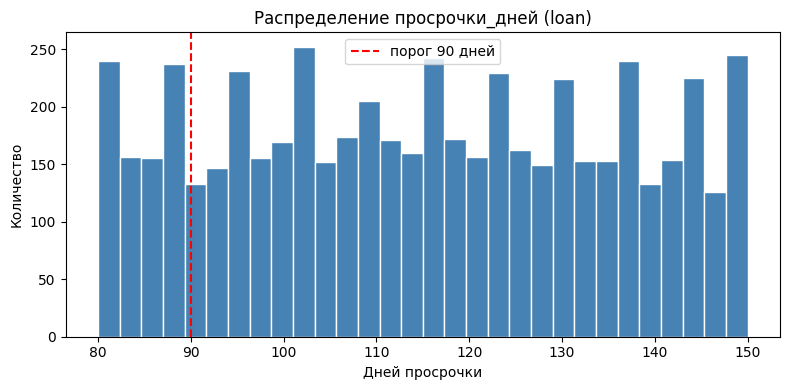

In [8]:
fig, axes = plt.subplots(1, 1, figsize=(8, 4))
axes.hist(dfs['loan']['просрочка_дней'], bins=30, color='steelblue', edgecolor='white')
axes.axvline(90, color='red', linestyle='--', label='порог 90 дней')
axes.set_title('Распределение просрочки_дней (loan)')
axes.set_xlabel('Дней просрочки')
axes.set_ylabel('Количество')
axes.legend()
plt.tight_layout()
plt.show()

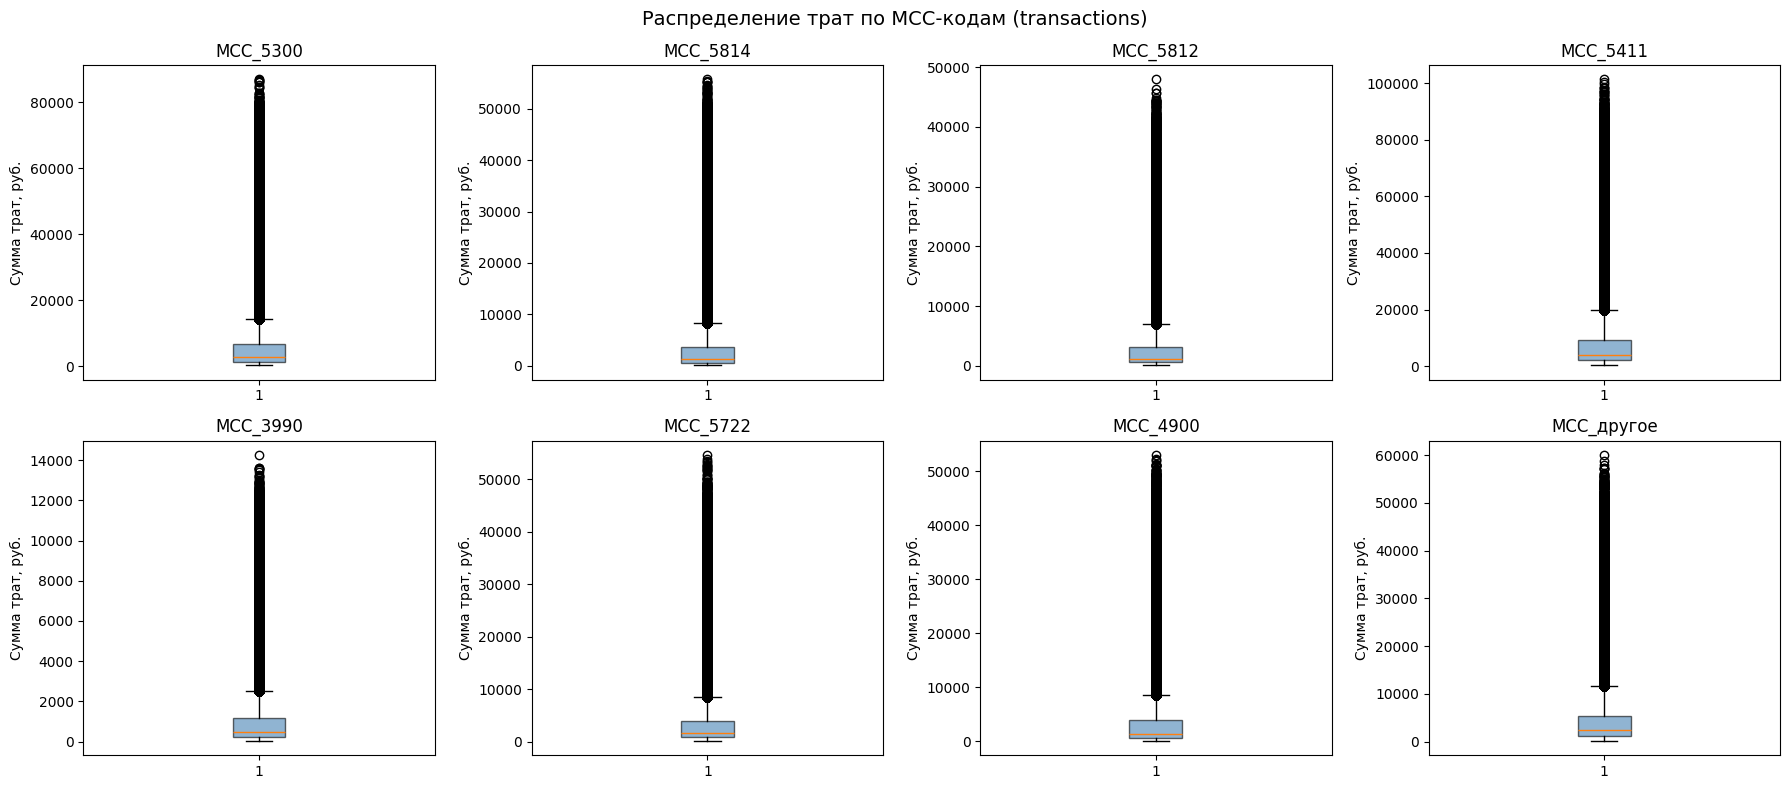

In [9]:
mcc_cols = ['MCC_5300','MCC_5814','MCC_5812','MCC_5411',
            'MCC_3990','MCC_5722','MCC_4900','MCC_другое']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(mcc_cols):
    axes[i].boxplot(dfs['transactions'][col], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(col)
    axes[i].set_ylabel('Сумма трат, руб.')
plt.suptitle('Распределение трат по MCC-кодам (transactions)', fontsize=14)
plt.tight_layout()
plt.show()

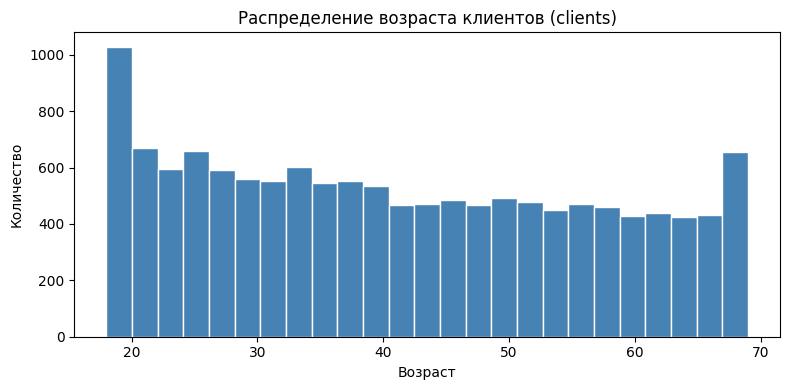

In [10]:
fig, axes = plt.subplots(1, 1, figsize=(8, 4))
axes.hist(dfs['clients']['возраст'], bins=25, color='steelblue', edgecolor='white')
axes.set_title('Распределение возраста клиентов (clients)')
axes.set_xlabel('Возраст')
axes.set_ylabel('Количество')
plt.tight_layout()
plt.show()

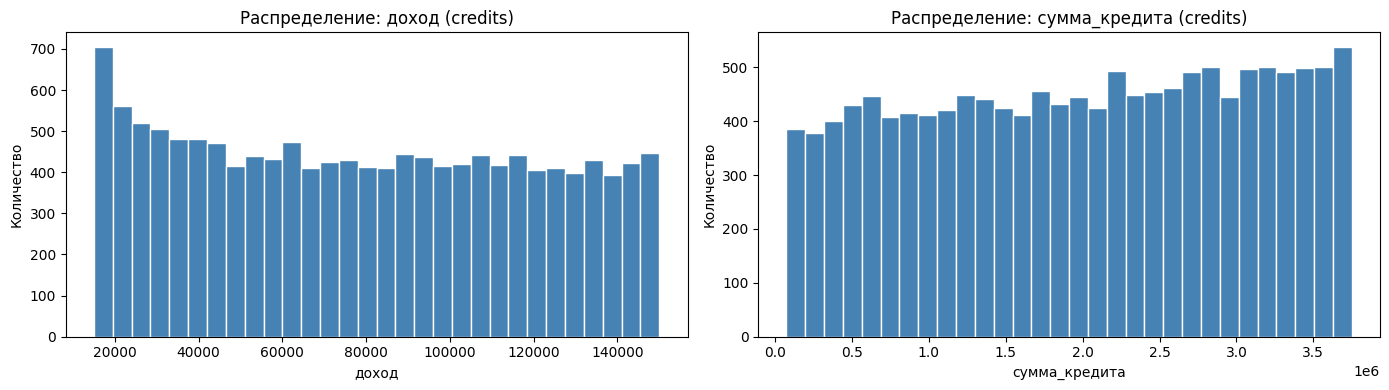

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col in zip(axes, ['доход', 'сумма_кредита']):
    ax.hist(dfs['credits'][col], bins=30, color='steelblue', edgecolor='white')
    ax.set_title(f'Распределение: {col} (credits)')
    ax.set_xlabel(col)
    ax.set_ylabel('Количество')
plt.tight_layout()
plt.show()

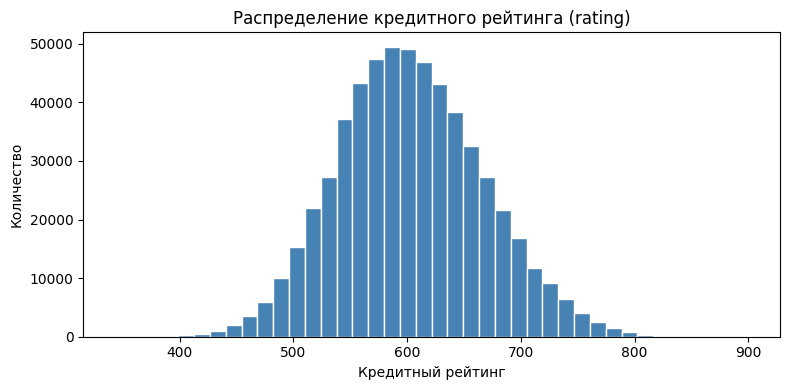

In [12]:
fig, axes = plt.subplots(1, 1, figsize=(8, 4))
axes.hist(dfs['rating']['кредитный_рейтинг'], bins=40, color='steelblue', edgecolor='white')
axes.set_title('Распределение кредитного рейтинга (rating)')
axes.set_xlabel('Кредитный рейтинг')
axes.set_ylabel('Количество')
plt.tight_layout()
plt.show()

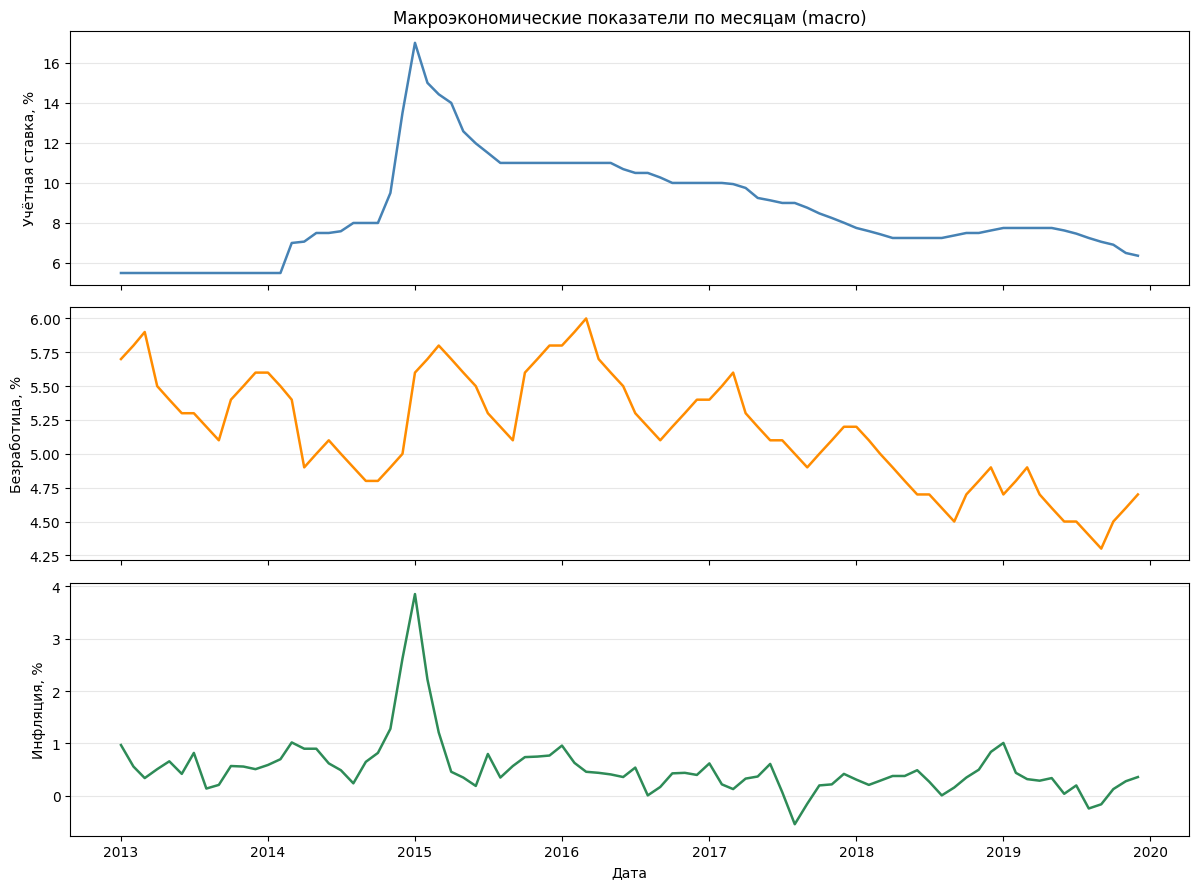

In [13]:
macro = dfs['macro'].copy()
macro['date'] = pd.to_datetime(macro['date'])
macro = macro.sort_values('date')

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
pairs = [
    ('учетная_ставка',       'Учётная ставка, %',     'steelblue'),
    ('уровень_безработицы',  'Безработица, %',         'darkorange'),
    ('инфляция',             'Инфляция, %',            'seagreen'),
]
for ax, (col, label, color) in zip(axes, pairs):
    ax.plot(macro['date'], macro[col], color=color, linewidth=1.8)
    ax.set_ylabel(label)
    ax.grid(axis='y', alpha=0.3)
axes[0].set_title('Макроэкономические показатели по месяцам (macro)')
axes[-1].set_xlabel('Дата')
plt.tight_layout()
plt.show()

Выводы по числовым распределениям:
- `loan.просрочка_дней`: min=80, хотя таргет считается от 90 — значит в таблице есть записи с просрочкой < 90 дней (они не дают таргет=1). При формировании целевой переменной фильтровать строго >= 90.
- Транзакции: сильная правосторонняя скошенность во всех MCC. Выбросы есть.
- `credits.доход`: min=15010, max=149988 — диапазон широкий, распределение равномерное. Подозрительно ровное — возможно синтетические данные.
- `rating`: рейтинг от 343 до 900, медиана 600 — стандартная шкала, всё ок.
- `macro.инфляция`: есть отрицательные значения (min=-0.54) — дефляция, это корректно для реальных данных.

In [14]:
print(f'Уникальные значения в категориальных данных.')

print('\nСемейное положение:')
print(dfs['clients']['семейное_положение'].value_counts())

print('\nНаличие иждивенцев:')
print(dfs['clients']['наличие_иждивенцев'].value_counts())

print('\nНаличие ипотеки:')
print(dfs['mortgage']['наличие_ипотеки'].value_counts())


Уникальные значения в категориальных данных.

Семейное положение:
семейное_положение
нет семьи      4584
разведённые    4519
есть семья     4397
Name: count, dtype: int64

Наличие иждивенцев:
наличие_иждивенцев
0    6956
1    6544
Name: count, dtype: int64

Наличие ипотеки:
наличие_ипотеки
1    6609
Name: count, dtype: int64


Выводы по категориальным данным:

- `Семейное положение`: три категории распределены почти равномерно (~4400–4584) — дисбаланса нет, кодирование простое.
- `Иждивенцы` распределены почти поровну — дисбаланса нет, признак можно использовать как есть без дополнительной обработки.
- `Ипотека`: в таблице mortgage только значение 1 — таблица содержит исключительно клиентов с ипотекой. Клиенты без ипотеки там отсутствуют. При join'е → left join + fillna().

In [15]:
threshold = 90
is_bad = dfs['loan']['просрочка_дней'] >= threshold
counts = is_bad.value_counts()
total = len(is_bad)

print("Распределение по качеству кредита:")
print(f"- менее {threshold} дней (Хорошие): {counts.get(False, 0)} ({counts.get(False, 0)/total*100:.2f}%)")
print(f"- {threshold} дней и более (Плохие):  {counts.get(True, 0)} ({counts.get(True, 0)/total*100:.2f}%)")
print(f"Всего записей: {total}")

Распределение по качеству кредита:
- менее 90 дней (Хорошие): 788 (14.33%)
- 90 дней и более (Плохие):  4712 (85.67%)
Всего записей: 5500


788 записей (14.3%) в `loan` имеют просрочку < 90 дней — они не дадут таргет=1, но присутствуют в таблице. При формировании целевой переменной фильтр `просрочка_дней >= 90` обязателен, иначе часть ложных дефолтов попадёт в таргет.

In [16]:
date_cols = {
    'loan':        'дата_начала_периода',
    'transactions':'date',
    'clients':     'дата_регистрации',
    'mortgage':    'дата_открытия',
    'rating':      'date',
    'macro':       'date',
    'grid':        'score_date',
}

print('Временные оси по таблицам:')
print(f"{'Таблица':<15} {'Столбец':<25} {'Min':<15} {'Max':<15}")
print('-' * 70)
for name, col in date_cols.items():
    dates = pd.to_datetime(dfs[name][col])
    print(f"{name.upper():<15} {col:<25} {str(dates.min().date()):<15} {str(dates.max().date()):<15}")

Временные оси по таблицам:
Таблица         Столбец                   Min             Max            
----------------------------------------------------------------------
LOAN            дата_начала_периода       2013-11-01      2019-12-01     
TRANSACTIONS    date                      2013-01-01      2019-12-01     
CLIENTS         дата_регистрации          2013-01-01      2019-12-01     
MORTGAGE        дата_открытия             2013-01-01      2019-12-01     
RATING          date                      2013-01-01      2019-12-01     
MACRO           date                      2013-01-01      2019-12-01     
GRID            score_date                2013-01-01      2019-12-01     


- Общий горизонт данных: январь 2013 — декабрь 2019 (7 лет) — все таблицы синхронизированы по времени.
- `loan` начинается с ноября 2013 — первые 10 месяцев (янв–окт 2013) дефолтов нет. Это значит, что наблюдения в grid за этот период получат таргет=0 не потому что клиент надёжный, а потому что данных о просрочках ещё нет. Нужно учитывать при анализе результатов.
- Горизонт прогноза 12 месяцев + max score_date = декабрь 2019 — наблюдения за последние 12 месяцев (янв–дек 2019) технически не могут иметь таргет=1, так как будущее за пределами датасета. Эти строки после формирования таргета получат 0 — не как факт надёжности, а как артефакт обрезки данных. Это важный риск для качества модели.

In [17]:
print("Уникальные клиенты по таблицам:")
print(f"{'Таблица':<15} {'Уникальных ID':<15}")
print('-' * 40)
for name, df in dfs.items():
    if 'ID' in df.columns:
        print(f"{name.upper():<15} {df['ID'].nunique():<15}")

Уникальные клиенты по таблицам:
Таблица         Уникальных ID  
----------------------------------------
LOAN            5500           
TRANSACTIONS    13500          
CLIENTS         13500          
CREDITS         13500          
MORTGAGE        6609           
RATING          13500          
GRID            13500          


**Выводы по этапу:**

- Пропусков и дубликатов нет ни в одной таблице. Все даты нужно конвертировать в `datetime` перед сборкой.
- Базовый размер когорты: 13 500 клиентов — все таблицы полные, кроме `loan` (5500) и `mortgage` (6609).
- `loan`: каждый клиент с просрочкой имеет ровно одну запись, множественных эпизодов нет. Есть записи с просрочкой < 90 дней (14.3%) — при  формировании таргета фильтр `просрочка_дней >= 90` обязателен. 5500 из 13 500 клиентов (~40%) имеют хотя бы один эпизод просрочки.
- `mortgage`: содержит только клиентов с ипотекой — join левый, остальным `fillna()`.
- Транзакции имеют сильную правостороннюю скошенность — для RF некритично.
- Горизонт данных: 2013–2019. Наблюдения за 2019 год получат таргет=0 как артефакт обрезки — реального дефолта в будущем мы не видим.
- Реальный дисбаланс классов оценим после формирования таргета.

## Сборка итоговой таблицы и формирование целевой переменной

In [18]:
# Конвертация дат
date_cols = {
    'loan': 'дата_начала_периода', 'transactions': 'date',
    'clients': 'дата_регистрации', 'mortgage': 'дата_открытия', 
    'rating': 'date', 'macro': 'date',
    'grid': 'score_date'
}

for table, col in date_cols.items():
    dfs[table][col] = pd.to_datetime(dfs[table][col])

print('Даты сконвертированы.')

Даты сконвертированы.


In [19]:
# Формирование целевой переменной
# дата_начала_периода — дата фиксации дефолта 90+ дней (не первый пропуск).
# Берём только просрочки >= 90 дней. И только первый по времени эпизод на клиента
# (в данных каждый клиент имеет ровно один эпизод — 5500 строк = 5500 уникальных ID).
loan_bad = (
    dfs['loan'][dfs['loan']['просрочка_дней'] >= 90]
    .sort_values('дата_начала_периода')
    .groupby('ID')
    .first()
    .reset_index()
)

print(f"Уникальных клиентов с дефолтом: {len(loan_bad)}")

df = dfs['grid'].copy()

df = df.merge(loan_bad[['ID', 'дата_начала_периода']], on='ID', how='left')

# Таргет = 1, если дата просрочки попадает в [score_date, score_date + 12 месяцев)
HORIZON = 12

df['target'] = (
    (df['дата_начала_периода'] >= df['score_date']) &
    (df['дата_начала_периода'] < df['score_date'] + pd.DateOffset(months=HORIZON))
).astype(int)

# Убираем строки, где дефолт уже произошёл ДО даты скоринга
df = df[~(df['дата_начала_периода'] < df['score_date'])]

Уникальных клиентов с дефолтом: 4712


In [20]:
# Проверка на одном клиенте
test_id = df['ID'].iloc[0]
print(f"\nПроверка на клиенте {test_id}:")
display(df[df['ID'] == test_id][['ID', 'score_date', 'дата_начала_периода', 'target']].head(10))


Проверка на клиенте IDF55109846:


,ID,score_date,дата_начала_периода,target
0,IDF55109846,2013-05-01,2014-12-01,0
1,IDF55109846,2013-06-01,2014-12-01,0
2,IDF55109846,2013-07-01,2014-12-01,0
3,IDF55109846,2013-08-01,2014-12-01,0
4,IDF55109846,2013-09-01,2014-12-01,0
5,IDF55109846,2013-10-01,2014-12-01,0
6,IDF55109846,2013-11-01,2014-12-01,0
7,IDF55109846,2013-12-01,2014-12-01,0
8,IDF55109846,2014-01-01,2014-12-01,1
9,IDF55109846,2014-02-01,2014-12-01,1


Проверяем на клиенте:
- score_date = 2013-05-01, просрочка 2014-12-01 — это 19 месяцев вперёд, за горизонтом → таргет=0
- score_date = 2014-01-01, просрочка 2014-12-01 — это 11 месяцев вперёд, в горизонте → таргет=1

**Таргет сформирован корректно.**

In [21]:
print(f"\nРазмер после формирования таргета: {df.shape}")
print(f"\nБаланс классов:\n{df['target'].value_counts()}")
print(df['target'].value_counts(normalize=True))

df.head(3)


Размер после формирования таргета: (438379, 4)

Баланс классов:
target
0    389015
1     49364
Name: count, dtype: int64
target
0    0.887394
1    0.112606
Name: proportion, dtype: float64


,ID,score_date,дата_начала_периода,target
0,IDF55109846,2013-05-01,2014-12-01,0
1,IDF55109846,2013-06-01,2014-12-01,0
2,IDF55109846,2013-07-01,2014-12-01,0


- 4712 уникальных клиентов с дефолтом (из 5500 записей в loan)
- Итоговый размер — 438379 строк.
- Дисбаланс классов: 89% / 11% — балансировка обязательна, учтём на этапе моделирования

In [22]:
# Сортировка — обязательна для merge_asof только по on-ключу
dfs['transactions'] = dfs['transactions'].sort_values('date')
dfs['rating'] = dfs['rating'].sort_values('date')
grid_sorted = df[['ID', 'score_date']].drop_duplicates().sort_values('score_date')

# Присоединение транзакций
transactions_asof = pd.merge_asof(
    grid_sorted,
    dfs['transactions'].rename(columns={'date': 'score_date'}),
    on='score_date',
    by='ID',
    direction='backward',
    allow_exact_matches=False
)
df = df.merge(transactions_asof, on=['ID', 'score_date'], how='left')
print(f"После join транзакций: {df.shape}")

# Присоединение кредитного рейтинга
rating_asof = pd.merge_asof(
    grid_sorted,
    dfs['rating'].rename(columns={'date': 'score_date'}),
    on='score_date',
    by='ID',
    direction='backward',
    allow_exact_matches=True
)
df = df.merge(rating_asof, on=['ID', 'score_date'], how='left')
print(f"После join рейтинга: {df.shape}")

После join транзакций: (438379, 12)
После join рейтинга: (438379, 13)


In [23]:
df = df.merge(dfs['clients'][['ID', 'возраст', 'семейное_положение', 'наличие_иждивенцев']], on='ID', how='left')
df = df.merge(dfs['credits'], on='ID', how='left')
print(f"После join clients и credits: {df.shape}")
print(df.columns.tolist())

После join clients и credits: (438379, 18)
['ID', 'score_date', 'дата_начала_периода', 'target', 'MCC_5300', 'MCC_5814', 'MCC_5812', 'MCC_5411', 'MCC_3990', 'MCC_5722', 'MCC_4900', 'MCC_другое', 'кредитный_рейтинг', 'возраст', 'семейное_положение', 'наличие_иждивенцев', 'доход', 'сумма_кредита']


In [24]:
# Ипотека — факт наличия на момент регистрации, фильтр по дате не нужен
df = df.merge(
    dfs['mortgage'][['ID', 'наличие_ипотеки']],
    on='ID', how='left'
)
df['наличие_ипотеки'] = df['наличие_ипотеки'].fillna(0).astype(int)
print(f"После join ипотеки: {df.shape}")

df.head(3)

После join ипотеки: (438379, 19)


,ID,score_date,дата_начала_периода,target,MCC_5300,MCC_5814,MCC_5812,MCC_5411,MCC_3990,MCC_5722,MCC_4900,MCC_другое,кредитный_рейтинг,возраст,семейное_положение,наличие_иждивенцев,доход,сумма_кредита,наличие_ипотеки
0,IDF55109846,2013-05-01,2014-12-01,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,692,41,разведённые,1,27035,1960785,0
1,IDF55109846,2013-06-01,2014-12-01,0,3267.59,1282.11,1457.96,5711.10,647.43,2374.78,4059.86,3657.35,688,41,разведённые,1,27035,1960785,0
2,IDF55109846,2013-07-01,2014-12-01,0,3196.58,2443.37,1334.20,5824.65,1067.55,2187.11,4592.26,3322.61,666,41,разведённые,1,27035,1960785,0


In [25]:
# Присоединение макроданных
macro_shifted = dfs['macro'].copy()
macro_shifted['score_date'] = macro_shifted['date'] + pd.DateOffset(months=1)
macro_shifted = macro_shifted.drop(columns='date')

df = df.merge(macro_shifted, on='score_date', how='left')

print(f"После join макро: {df.shape}")

После join макро: (438379, 22)


In [26]:
# Финальная очистка
df = df.drop(columns=['дата_начала_периода'], errors='ignore')

print(f"\nИтоговая таблица: {df.shape}")
print(f"\nСтолбцы:\n{df.columns.tolist()}")
print(f"\nПропуски:\n{df.isnull().sum()}")

display(df.head(3))


Итоговая таблица: (438379, 21)

Столбцы:
['ID', 'score_date', 'target', 'MCC_5300', 'MCC_5814', 'MCC_5812', 'MCC_5411', 'MCC_3990', 'MCC_5722', 'MCC_4900', 'MCC_другое', 'кредитный_рейтинг', 'возраст', 'семейное_положение', 'наличие_иждивенцев', 'доход', 'сумма_кредита', 'наличие_ипотеки', 'учетная_ставка', 'уровень_безработицы', 'инфляция']

Пропуски:
ID                         0
score_date                 0
target                     0
MCC_5300               13500
MCC_5814               13500
MCC_5812               13500
MCC_5411               13500
MCC_3990               13500
MCC_5722               13500
MCC_4900               13500
MCC_другое             13500
кредитный_рейтинг          0
возраст                    0
семейное_положение         0
наличие_иждивенцев         0
доход                      0
сумма_кредита              0
наличие_ипотеки            0
учетная_ставка           152
уровень_безработицы      152
инфляция                 152
dtype: int64


,ID,score_date,target,MCC_5300,MCC_5814,MCC_5812,MCC_5411,MCC_3990,MCC_5722,MCC_4900,...,кредитный_рейтинг,возраст,семейное_положение,наличие_иждивенцев,доход,сумма_кредита,наличие_ипотеки,учетная_ставка,уровень_безработицы,инфляция
0,IDF55109846,2013-05-01,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,692,41,разведённые,1,27035,1960785,0,5.5,5.5,0.51
1,IDF55109846,2013-06-01,0,3267.59,1282.11,1457.96,5711.10,647.43,2374.78,4059.86,...,688,41,разведённые,1,27035,1960785,0,5.5,5.4,0.66
2,IDF55109846,2013-07-01,0,3196.58,2443.37,1334.20,5824.65,1067.55,2187.11,4592.26,...,666,41,разведённые,1,27035,1960785,0,5.5,5.3,0.42


В таблице обнаружено два типа структурных пропусков:

- 13 500 пропусков в транзакциях и рейтинге — первое наблюдение каждого
  клиента: данных за предыдущий месяц ещё нет. Заполнение нулями или
  медианой некорректно — это исказило бы поведенческую динамику. Выбран
  подход удаления: модель будет применяться начиная со второго месяца
  наблюдения за клиентом.

- 152 пропуска в макропоказателях — наблюдения за январь 2013: макроданные
  за декабрь 2012 в датасете отсутствуют. Удаляем по той же причине.

In [27]:
df = df.dropna(subset=['MCC_5300', 'кредитный_рейтинг'])

print(f"После удаления первых наблюдений: {df.shape}")
print(f"Пропуски:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

После удаления первых наблюдений: (424879, 21)
Пропуски:
Series([], dtype: int64)


In [28]:
df = df.dropna(subset=['учетная_ставка'])

print(f"После удаления пропусков макро: {df.shape}")

После удаления пропусков макро: (424879, 21)


**Выводы по этапу:**

- Сформирована итоговая таблица: 424 879 наблюдений, 21 столбец (`ID`, `score_date`, `target` + 18 признаков).
- Утечка данных из будущего предотвращена: транзакции присоединены строго за предыдущий месяц (`merge_asof`, `allow_exact_matches=False`), рейтинг и макропоказатели — за текущий месяц (данные актуальны на дату скоринга).
- Ипотека присоединена без фильтра по дате — она является причиной скоринга, а не будущим событием.
- Удалены первые наблюдения каждого клиента (13 500 строк) — история транзакций за предыдущий месяц отсутствует, заполнение некорректно. Модель применяется начиная со второго месяца наблюдения за клиентом.
- Дисбаланс классов: 89% / 11% — балансировка обязательна на этапе моделирования.

## Создание новых признаков

In [29]:
df.columns

Index(['ID', 'score_date', 'target', 'MCC_5300', 'MCC_5814', 'MCC_5812',
       'MCC_5411', 'MCC_3990', 'MCC_5722', 'MCC_4900', 'MCC_другое',
       'кредитный_рейтинг', 'возраст', 'семейное_положение',
       'наличие_иждивенцев', 'доход', 'сумма_кредита', 'наличие_ипотеки',
       'учетная_ставка', 'уровень_безработицы', 'инфляция'],
      dtype='str')

In [30]:
print(f"\nПропуски:\n{df.isnull().sum()}")


Пропуски:
ID                     0
score_date             0
target                 0
MCC_5300               0
MCC_5814               0
MCC_5812               0
MCC_5411               0
MCC_3990               0
MCC_5722               0
MCC_4900               0
MCC_другое             0
кредитный_рейтинг      0
возраст                0
семейное_положение     0
наличие_иждивенцев     0
доход                  0
сумма_кредита          0
наличие_ипотеки        0
учетная_ставка         0
уровень_безработицы    0
инфляция               0
dtype: int64


In [31]:
# 1. Долговая нагрузка
df['debt_load'] = df['сумма_кредита'] / df['доход'].replace(0, np.nan)

# 2. Суммарные траты
mcc_cols = ['MCC_5300', 'MCC_5814', 'MCC_5812', 'MCC_5411',
            'MCC_3990', 'MCC_5722', 'MCC_4900', 'MCC_другое']
df['total_spending'] = df[mcc_cols].sum(axis=1)

# 3. Доля обязательных трат
df['essential_ratio'] = (
    (df['MCC_5411'] + df['MCC_4900'])
    / df['total_spending'].replace(0, np.nan)
)

df = df.sort_values(['ID', 'score_date']).reset_index(drop=True)

# 4. Динамика трат за 3 месяца: текущие / средние за 3 предыдущих месяца.
# Значение < 1 — траты падают (ранний сигнал финансового стресса).Значение > 1 — траты растут.
df['spending_3m_ratio'] = (
    df['total_spending']
    / df.groupby('ID')['total_spending']
        .shift(1).rolling(window=3, min_periods=1).mean()
)

# 5. Изменение кредитного рейтинга за 1 месяц.
# Отрицательное — рейтинг ухудшается, положительное — улучшается.
df['rating_change_1m'] = (
    df['кредитный_рейтинг'] - df.groupby('ID')['кредитный_рейтинг'].shift(1)
)

# Заполняем возможные пропуски после деления на 0
df['debt_load'] = df['debt_load'].fillna(0)
df['essential_ratio'] = df['essential_ratio'].fillna(0)

# Заполняем пропуски в лаговых признаках. NaN возникает у первых наблюдений клиента, где нет истории.
# 1.0 = нет динамики (нейтральное значение), 0 = нет изменения рейтинга.
df['spending_3m_ratio'] = df['spending_3m_ratio'].fillna(1.0)
df['rating_change_1m'] = df['rating_change_1m'].fillna(0)


print("Новые признаки созданы")
display(df[['debt_load', 'total_spending', 'essential_ratio',
           'spending_3m_ratio', 'rating_change_1m']].describe().T)

Новые признаки созданы


,count,mean,std,min,25%,50%,75%,max
debt_load,424879.0,34.695201,35.275909,0.506239,12.439334,23.809872,42.627152,242.970580
total_spending,424879.0,44332.363840,51648.173846,1214.880000,10317.705000,19549.470000,64484.630000,309029.080000
essential_ratio,424879.0,0.360467,0.048904,0.244926,0.324505,0.349219,0.392272,0.492178
spending_3m_ratio,424879.0,1.147079,1.532755,0.054540,0.827109,1.042001,1.224983,83.133781
rating_change_1m,424879.0,-2.228950,10.960648,-57.000000,-9.000000,-2.000000,5.000000,50.000000


**Выводы по этапу:**

- `debt_load`: median=23.8, max=242.9 — сильный разброс, есть экстремальные значения. Для RF некритично, но признак информативный: клиент с нагрузкой в 100+ доходов явно в зоне риска. Признак введен для прямой оценки долговой нагрузки: чем выше отношение платежей к доходу, тем меньше «финансовой подушки» и выше вероятность дефолта при потере дохода.
- `total_spending`: min=1214.88, mean=44k, std=51k. Широкий диапазон трат отражает реальную вариативность поведения. Суммарные траты служат показателем для уровня жизни и финансовой активности: резкое падение или аномальный рост расходов могут сигнализировать о стрессе или изменении финансового статуса.
- `essential_ratio`: median=0.347, std=0.079 — признак компактный, без выбросов. Доля обязательных трат у большинства клиентов около 35%, что выглядит реалистично. Гипотеза: высокая доля обязательных расходов (ЖКХ, еда) снижает финансовую гибкость. Клиент с ratio > 0.8 не сможет сократить расходы при ухудшении ситуации, что повышает риск просрочки.
- `spending_3m_ratio`: median=1.04, mean=1.15, std=1.53. Медиана близка к 1.0 — у большинства клиентов траты стабильны. Но std большой: max=83.1 — случай, когда текущие траты в 83 раза выше среднего за 3 предыдущих месяца (вероятно, предыдущие месяцы были близки к нулю). Для RF некритично, но признак хорошо разделяет стабильных и нестабильных клиентов. Mean=1.15 — в среднем траты незначительно растут, что ожидаемо с инфляцией.
- `rating_change_1m`: median=-2, mean=-2.23, std=10.96. Среднее и медиана отрицательные — рейтинг в среднем медленно ухудшается со временем, что согласуется с ростом просрочек в портфеле. Диапазон от -57 до +50 пунктов — разумный для одномесячного изменения. Выбросы в отрицательную сторону (резкое падение рейтинга) — опережающий сигнал дефолта, недоступный в статическом скоринге.


## Анализ итоговой таблицы и баланса классов

In [32]:
display(df.head())

,ID,score_date,target,MCC_5300,MCC_5814,MCC_5812,MCC_5411,MCC_3990,MCC_5722,MCC_4900,...,сумма_кредита,наличие_ипотеки,учетная_ставка,уровень_безработицы,инфляция,debt_load,total_spending,essential_ratio,spending_3m_ratio,rating_change_1m
0,IDF54896351,2013-04-01,0,2224.47,909.12,858.41,3911.52,428.48,1464.28,2616.17,...,2506575,1,5.5,5.9,0.34,142.152498,14573.70,0.447909,1.000000,0.0
1,IDF54896351,2013-05-01,0,1986.07,1729.86,857.94,3769.95,682.43,1497.97,3011.24,...,2506575,1,5.5,5.5,0.51,142.152498,15746.17,0.430656,1.080451,27.0
2,IDF54896351,2013-06-01,0,2120.91,2737.69,798.60,3436.64,720.28,1389.35,2511.64,...,2506575,1,5.5,5.4,0.66,142.152498,15860.32,0.375042,1.046200,5.0
3,IDF54896351,2013-07-01,0,2034.34,3429.41,930.14,3783.15,671.98,1447.39,1864.56,...,2506575,1,5.5,5.3,0.42,142.152498,16380.58,0.344781,1.064130,-4.0
4,IDF54896351,2013-08-01,0,2099.40,2852.99,906.69,3635.57,425.58,1487.86,1148.91,...,2506575,1,5.5,5.3,0.82,142.152498,15376.64,0.311153,0.961299,4.0


In [33]:
print(f'Размер итоговой таблицы: {df.shape}')
print(f'\nТипы данных: \n{df.dtypes}')
print(f'\nПропуски: \n{df.isnull().sum()}')

Размер итоговой таблицы: (424879, 26)

Типы данных: 
ID                                str
score_date             datetime64[us]
target                          int64
MCC_5300                      float64
MCC_5814                      float64
MCC_5812                      float64
MCC_5411                      float64
MCC_3990                      float64
MCC_5722                      float64
MCC_4900                      float64
MCC_другое                    float64
кредитный_рейтинг               int64
возраст                         int64
семейное_положение                str
наличие_иждивенцев              int64
доход                           int64
сумма_кредита                   int64
наличие_ипотеки                 int64
учетная_ставка                float64
уровень_безработицы           float64
инфляция                      float64
debt_load                     float64
total_spending                float64
essential_ratio               float64
spending_3m_ratio             float

In [34]:
class_counts = df['target'].value_counts()
class_pct = df['target'].value_counts(normalize=True) * 100

print("Баланс классов:")
print(f"  Класс 0 (нет дефолта): {class_counts[0]:>7} ({class_pct[0]:.1f}%)")
print(f"  Класс 1 (дефолт):      {class_counts[1]:>7} ({class_pct[1]:.1f}%)")
print(f"  Соотношение 0/1:       {class_counts[0]/class_counts[1]:.1f}x")

Баланс классов:
  Класс 0 (нет дефолта):  377564 (88.9%)
  Класс 1 (дефолт):        47315 (11.1%)
  Соотношение 0/1:       8.0x


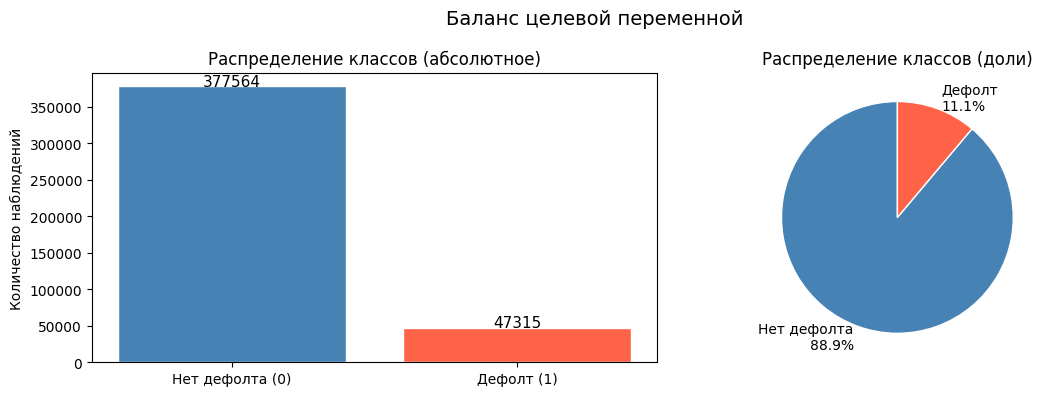

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Нет дефолта (0)', 'Дефолт (1)'],
            class_counts.values,
            color=['steelblue', 'tomato'],
            edgecolor='white')
axes[0].set_title('Распределение классов (абсолютное)')
axes[0].set_ylabel('Количество наблюдений')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 500, str(v), ha='center', fontsize=11)

axes[1].pie(class_pct.values,
            labels=[f'Нет дефолта\n{class_pct[0]:.1f}%',
                    f'Дефолт\n{class_pct[1]:.1f}%'],
            colors=['steelblue', 'tomato'],
            startangle=90,
            wedgeprops=dict(edgecolor='white'))
axes[1].set_title('Распределение классов (доли)')

plt.suptitle('Баланс целевой переменной', fontsize=14)
plt.tight_layout()
plt.show()

**Выводы по этапу:**

- Таблица полная: 424879 строк, 24 столбца, пропусков нет.
- Единственный нечисловой признак-фича — семейное_положение (`object`). Потребует кодирования перед моделированием.
- Дисбаланс классов: 88.7% / 11.3%, соотношение ~8:1. Балансировка обязательна. Варианты: `class_weight='balanced'`, `RandomOverSampler`, `SMOTE`. Выберем лучший на этапе базовых моделей.

## Моделирование: базовые модели

In [36]:
df = df[df['score_date'] < pd.Timestamp('2019-01-01')].copy()

test_start  = pd.Timestamp('2018-01-01')
calib_start = pd.Timestamp('2017-01-01')

train = df[df['score_date'] < calib_start].copy()
calib = df[(df['score_date'] >= calib_start) & (df['score_date'] < test_start)].copy()
test  = df[df['score_date'] >= test_start].copy()

print(f"Train: {train.shape}")
print(f"Calib: {calib.shape}")
print(f"Test:  {test.shape}")

print(f"\nПериод train: {train['score_date'].min().date()} — {train['score_date'].max().date()}")
print(f"Период calib: {calib['score_date'].min().date()} — {calib['score_date'].max().date()}")
print(f"Период test:  {test['score_date'].min().date()} — {test['score_date'].max().date()}")

for name, y in [('train', train['target']), ('calib', calib['target']), ('test', test['target'])]:
    print(f"{name}: target mean = {y.mean():.3f} | class 1: {y.sum()} / {len(y)}")

Train: (153186, 26)
Calib: (77551, 26)
Test:  (92346, 26)

Период train: 2013-02-01 — 2016-12-01
Период calib: 2017-01-01 — 2017-12-01
Период test:  2018-01-01 — 2018-12-01
train: target mean = 0.166 | class 1: 25424 / 153186
calib: target mean = 0.101 | class 1: 7810 / 77551
test: target mean = 0.106 | class 1: 9746 / 92346


In [37]:
# Формирование X, y для каждой выборки

DROP_COLS = ['ID', 'score_date', 'target']

X_train = train.drop(columns=DROP_COLS)
y_train = train['target']

X_calib = calib.drop(columns=DROP_COLS)
y_calib = calib['target']

X_test = test.drop(columns=DROP_COLS)
y_test = test['target']

print(f"X_train: {X_train.shape}")
print(f"X_calib: {X_calib.shape}")
print(f"X_test:  {X_test.shape}")

print(f"\nПризнаки: {X_train.columns.tolist()}")

X_train: (153186, 23)
X_calib: (77551, 23)
X_test:  (92346, 23)

Признаки: ['MCC_5300', 'MCC_5814', 'MCC_5812', 'MCC_5411', 'MCC_3990', 'MCC_5722', 'MCC_4900', 'MCC_другое', 'кредитный_рейтинг', 'возраст', 'семейное_положение', 'наличие_иждивенцев', 'доход', 'сумма_кредита', 'наличие_ипотеки', 'учетная_ставка', 'уровень_безработицы', 'инфляция', 'debt_load', 'total_spending', 'essential_ratio', 'spending_3m_ratio', 'rating_change_1m']


- Размеры выборок `train`, `calib`,  `test` соответствуют условиям проекта.
- Периоды не пересекаются, хронология соблюдена.
- 23 признака в `X`. `ID`, `score_dat`e, `target` исключены.
- `семейное_положение` присутствует — сделаем кодирование в пайплайне.

In [38]:
for name, y in [('train', y_train), ('calib', y_calib), ('test', y_test)]:
    print(f"{name}: target mean = {y.mean():.3f} | class 1: {y.sum()} / {len(y)}")

train: target mean = 0.166 | class 1: 25424 / 153186
calib: target mean = 0.101 | class 1: 7810 / 77551
test: target mean = 0.106 | class 1: 9746 / 92346


Баланс классов стабильный во всех трёх выборках: `train` 16.6% / `calib` 10.1% / `test` 10.6% — выборки репрезентативны и сопоставимы.

*Примечание: выбор реализации GroupTimeSeriesSplit*

В проекте используется собственная реализация `GroupTimeSeriesSplit` на базе `sklearn.model_selection.BaseCrossValidator`, а не готовая из `mlxtend.evaluate.time_series`.

**Причина:** реализация из `mlxtend` делит данные по индексам строк, не учитывая временные метки. При неравномерном распределении наблюдений по месяцам это не гарантирует корректное временное разбиение: в валидацию могут попасть наблюдения из более раннего периода, чем в `train`.

**Наша реализация** делит по уникальным значениям `score_date`: train-фолд всегда содержит более ранние даты, чем val-фолд. Это
принципиально для задачи поведенческого скоринга, где утечка данных из будущего в прошлое недопустима.

In [39]:
# GroupTimeSeriesSplit
class GroupTimeSeriesSplit(BaseCrossValidator):
    def __init__(self, n_splits=3):
        self.n_splits = n_splits

    def split(self, X, y=None, groups=None):
        unique_times = np.sort(np.unique(groups))
        fold_size = len(unique_times) // (self.n_splits + 1)

        for i in range(1, self.n_splits + 1):
            train_end = fold_size * i
            val_end   = fold_size * (i + 1)

            train_times = unique_times[:train_end]
            val_times   = unique_times[train_end:val_end]

            train_idx = np.where(np.isin(groups, train_times))[0]
            val_idx   = np.where(np.isin(groups, val_times))[0]

            yield train_idx, val_idx

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits

In [40]:
cat_features     = ['семейное_положение']
binary_features  = ['наличие_иждивенцев', 'наличие_ипотеки']
num_features     = [c for c in X_train.columns 
                    if c not in cat_features + binary_features]

# Явный порядок категорий для OrdinalEncoder
семейное_положение_order = [['нет семьи', 'разведённые', 'есть семья']]

# Препроцессор для RF (OrdinalEncoder, без масштабирования)
preprocessor_rf = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(
            categories=семейное_положение_order,
            handle_unknown='use_encoded_value',
            unknown_value=-1
        ), cat_features)
    ],
    remainder='passthrough'
)

# Препроцессор для LR (OHE + StandardScaler на числовых)
preprocessor_lr = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(
            drop='first',
            handle_unknown='error',
            sparse_output=False
        ), cat_features),
        ('num', StandardScaler(), num_features),
    ],
    remainder='passthrough'
)

def make_pipeline_rf(model):
    return Pipeline([
        ('preprocessor', preprocessor_rf),
        ('model', model)
    ])

def make_pipeline_lr(model):
    return Pipeline([
        ('preprocessor', preprocessor_lr),
        ('model', model)
    ])

In [41]:
# Кросс-валидация и базовые модели
cv_groups = train['score_date'].values
gtss = GroupTimeSeriesSplit(n_splits=CV_FOLDS)

models = {
    'LR (no balance)': make_pipeline_lr(
        LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    ),
    'RF (no balance)': make_pipeline_rf(
        RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=4)
    ),
    'LR (balanced)': make_pipeline_lr(
        LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,
                           class_weight='balanced')
    ),
    'RF (balanced)': make_pipeline_rf(
        RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE,
                               class_weight='balanced', n_jobs=4)
    ),
}

results = {}
for name, pipeline in models.items():
    scores = cross_val_score(
        pipeline, X_train, y_train,
        cv=gtss,
        groups=cv_groups,
        scoring='roc_auc'
    )
    results[name] = scores

for name, scores in results.items():
    print(f"{name:<25} ROC-AUC: {scores.mean():.4f} ± {scores.std():.4f}")

LR (no balance)           ROC-AUC: 0.7942 ± 0.0448
RF (no balance)           ROC-AUC: 0.8337 ± 0.0566
LR (balanced)             ROC-AUC: 0.7970 ± 0.0474
RF (balanced)             ROC-AUC: 0.8400 ± 0.0529


**Выводы по этапу:**

- `RF` превосходит `LR` в обоих случаях (~0.84 vs ~0.80) — в данных присутствуют нелинейные зависимости, которые линейная модель не улавливает.
- Балансировка практически не влияет ни на `LR` (+0.003), ни на `RF` (+0.006) — дисбаланс 11/89 не настолько критичен, чтобы существенно менять `ROC-AUC`.
- **RF (balanced) — лучшая базовая модель: `ROC-AUC` 0.8400 ± 0.0529.**


## Финальная модель: Random Forest + Optuna

In [42]:
# Бизнес-метрики
def missed_defaults_rate(y_true, y_pred):
    tp = ((y_pred == 1) & (y_true == 1)).sum()
    fn = ((y_pred == 0) & (y_true == 1)).sum()
    return fn / (fn + tp) if (fn + tp) > 0 else 0

def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    tp = ((y_pred == 1) & (y_true == 1)).sum()
    fp = ((y_pred == 1) & (y_true == 0)).sum()
    tn = ((y_pred == 0) & (y_true == 0)).sum()
    fn = ((y_pred == 0) & (y_true == 1)).sum()
    n  = len(y_true)
    approval_rate      = (fn + tn) / n
    default_rate       = fn / (fn + tn) if (fn + tn) > 0 else 0
    missed_def_rate    = fn / (fn + tp) if (fn + tp) > 0 else 0
    return {
        'approval_rate':       approval_rate,
        'default_rate':        default_rate,
        'missed_defaults_rate': missed_def_rate,
    }

In [43]:
# Optuna: подбор гиперпараметров RF
OPTUNA_CACHE = 'optuna_study.joblib'

def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 400, 700),
        'max_depth':         trial.suggest_int('max_depth', 4, 8),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 20, 60),
        'max_features':      trial.suggest_float('max_features', 0.05, 0.25),
        'class_weight':      'balanced',
        'random_state':      RANDOM_STATE,
        'n_jobs':            4
    }

    rf = RandomForestClassifier(**params)
    pipeline = make_pipeline_rf(rf)

    fold_scores = []
    for train_idx, val_idx in gtss.split(X_train, y_train, groups=cv_groups):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        pipeline.fit(X_tr, y_tr)
        y_prob = pipeline.predict_proba(X_val)[:, 1]
        y_pred = (y_prob >= 0.5).astype(int)

        mdr = missed_defaults_rate(y_val.values, y_pred)
        fold_scores.append(mdr)

    return np.mean(fold_scores)


if os.path.exists(OPTUNA_CACHE):
    study = joblib.load(OPTUNA_CACHE)
    print("Optuna study загружена из кэша")
else:
    study = optuna.create_study(
        direction='minimize',
        sampler=TPESampler(seed=RANDOM_STATE)
    )
    study.optimize(objective, n_trials=30, show_progress_bar=True)
    joblib.dump(study, OPTUNA_CACHE)
    print("Optuna study сохранена в кэш")

print(f"\nЛучший missed_defaults_rate: {study.best_value:.4f}")
print(f"Лучшие параметры:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

Optuna study загружена из кэша

Лучший missed_defaults_rate: 0.2022
Лучшие параметры:
  n_estimators: 630
  max_depth: 4
  min_samples_leaf: 21
  max_features: 0.12701121589315795


Финальные параметры модели: `n_estimators`: 630, `max_depth`: 4, `min_samples_leaf`: 21, `max_features`: 0.127, `class_weight`: balanced.

In [44]:
# Сравнение моделей через кросс-валидацию на train
def cv_evaluate(pipeline, X, y, groups, cv):
    """Оценка модели через CV — только на train."""
    y_prob_all = np.zeros(len(y))
    y_true_all = np.zeros(len(y))

    for train_idx, val_idx in cv.split(X, y, groups=groups):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        pipeline.fit(X_tr, y_tr)
        y_prob_all[val_idx] = pipeline.predict_proba(X_val)[:, 1]
        y_true_all[val_idx] = y_val.values

    # Считаем метрики по всем OOF предсказаниям
    metrics = compute_metrics(y_true_all, y_prob_all, threshold=0.5)
    metrics['roc_auc'] = roc_auc_score(y_true_all, y_prob_all)
    metrics['accuracy'] = accuracy_score(
        y_true_all, (y_prob_all >= 0.5).astype(int)
    )
    return metrics


# Базовые модели
comparison = {}
for name, pipeline in models.items():
    comparison[name] = cv_evaluate(
        pipeline, X_train, y_train, cv_groups, gtss
    )

# Финальная модель RF + Optuna — тоже через CV
best_rf_cv = make_pipeline_rf(RandomForestClassifier(
    **study.best_params,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=4,
))
comparison['RF (optuna)'] = cv_evaluate(
    best_rf_cv, X_train, y_train, cv_groups, gtss
)

df_comparison = pd.DataFrame(comparison).T
df_comparison = df_comparison[['roc_auc', 'accuracy',
                                'approval_rate', 'default_rate',
                                'missed_defaults_rate']]
df_comparison.columns = ['ROC-AUC', 'Accuracy',
                          'Approval Rate', 'Default Rate',
                          'Missed Defaults Rate']


print("\nСравнение моделей (OOF CV на train):")
display(df_comparison.round(4))


Сравнение моделей (OOF CV на train):


,ROC-AUC,Accuracy,Approval Rate,Default Rate,Missed Defaults Rate
LR (no balance),0.8486,0.8564,0.9465,0.1210,0.8237
RF (no balance),0.8822,0.8718,0.9382,0.1095,0.7388
LR (balanced),0.8507,0.7863,0.7261,0.0543,0.2836
RF (balanced),0.8863,0.8626,0.8726,0.0854,0.5360
RF (optuna),0.8442,0.7409,0.6578,0.0426,0.2014


In [45]:
best_rf = RandomForestClassifier(
    **study.best_params,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=4,
)
best_pipeline = make_pipeline_rf(best_rf)
best_pipeline.fit(X_train, y_train)
print("Финальная модель обучена")

Финальная модель обучена


**Сравнение базовых моделей:**

- `RF` превосходит `LR` по `ROC-AU`C (~0.88 vs ~0.85) — нелинейные зависимости в данных присутствуют.
- Балансировка критична для бизнес-метрик: без неё `missed_defaults_rate` превышает 73% — модель пропускает большинство дефолтов.
- `LR (balanced)` даёт приемлемый `MDR` (0.284), но значительно уступает `RF` по всем метрикам.

**Финальная модель RF (Optuna):**

- Лучший `missed_defaults_rate` среди всех моделей: 0.201 — модель пропускает наименьшую долю дефолтов.
- `Default rate`: 0.043 — минимальный среди всех моделей.
- `Approval rate`: 0.658 — модель строже фильтрует клиентов, чем базовые.
- `ROC-AUC` (0.844) ниже базового RF (0.886) — `Optuna` оптимизировала под `missed_defaults_rate`, а не под `ROC-AUC`, что соответствует задаче.

**`RF (optuna)` выбран как финальная модель — единственная, обеспечивающая приемлемый баланс между охватом надёжных клиентов
и контролем пропущенных дефолтов.**


## Калибровка модели

In [46]:
# Применяем препроцессор отдельно, калибруем только модель
preprocessor_fitted = best_pipeline.named_steps['preprocessor']
rf_model = best_pipeline.named_steps['model']

X_calib_transformed = preprocessor_fitted.transform(X_calib)

calibrated_rf = CalibratedClassifierCV(
    rf_model,
    method='isotonic',
    cv=None
)
calibrated_rf.fit(X_calib_transformed, y_calib)

# Собираем новый пайплайн: препроцессор + откалиброванная модель
calibrated_pipeline = Pipeline([
    ('preprocessor', preprocessor_fitted),
    ('model', calibrated_rf)
])
print("Калибровка завершена")

Калибровка завершена


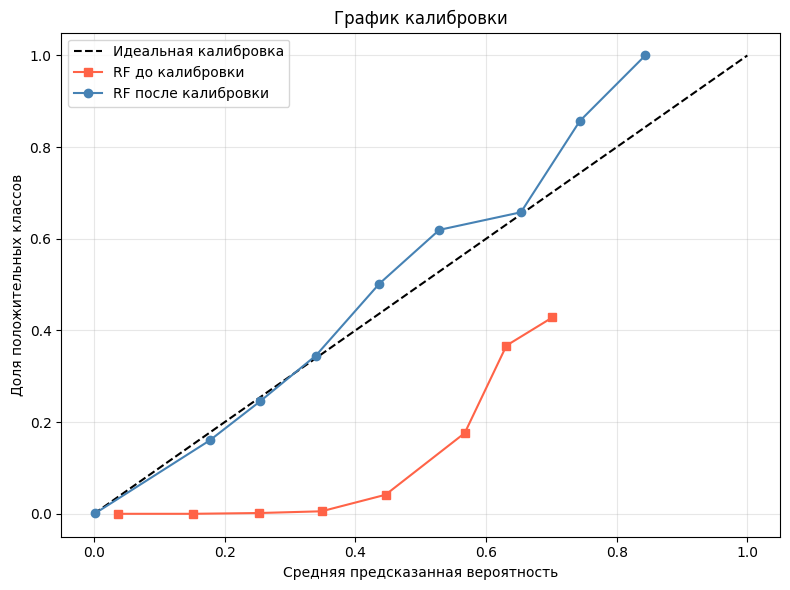

Brier Score до калибровки:    0.1324
Brier Score после калибровки: 0.0696


In [47]:
y_prob_before = best_pipeline.predict_proba(X_calib)[:, 1]
y_prob_after  = calibrated_pipeline.predict_proba(X_calib)[:, 1]

frac_before, mean_before = calibration_curve(y_calib, y_prob_before, n_bins=10)
frac_after,  mean_after  = calibration_curve(y_calib, y_prob_after,  n_bins=10)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], 'k--', label='Идеальная калибровка')
ax.plot(mean_before, frac_before, 's-', color='tomato',    label='RF до калибровки')
ax.plot(mean_after,  frac_after,  'o-', color='steelblue', label='RF после калибровки')
ax.set_xlabel('Средняя предсказанная вероятность')
ax.set_ylabel('Доля положительных классов')
ax.set_title('График калибровки')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

brier_before = brier_score_loss(y_calib, y_prob_before)
brier_after  = brier_score_loss(y_calib, y_prob_after)
print(f"Brier Score до калибровки:    {brier_before:.4f}")
print(f"Brier Score после калибровки: {brier_after:.4f}")

In [48]:
# Бизнес-метрики до и после калибровки
metrics_before = compute_metrics(y_calib.values, y_prob_before, threshold=0.5)
metrics_before['roc_auc'] = roc_auc_score(y_calib, y_prob_before)

metrics_after = compute_metrics(y_calib.values, y_prob_after, threshold=0.5)
metrics_after['roc_auc'] = roc_auc_score(y_calib, y_prob_after)

df_calib_comparison = pd.DataFrame({
    'До калибровки':    metrics_before,
    'После калибровки': metrics_after,
}).T

df_calib_comparison = df_calib_comparison[
    ['roc_auc', 'approval_rate', 'default_rate', 'missed_defaults_rate']
]
df_calib_comparison.columns = [
    'ROC-AUC', 'Approval Rate', 'Default Rate', 'Missed Defaults Rate'
]
print("Бизнес-метрики до и после калибровки (threshold=0.5):")
display(df_calib_comparison.round(4))

Бизнес-метрики до и после калибровки (threshold=0.5):


,ROC-AUC,Approval Rate,Default Rate,Missed Defaults Rate
До калибровки,0.8968,0.6438,0.0040,0.0256
После калибровки,0.8924,0.9967,0.0989,0.9789


**Выводы по этапу:**

- До калибровки `RF` сильно занижает вероятности — красная кривая далеко от диагонали, особенно в диапазоне 0.3–0.7.
- После калибровки синяя кривая значительно приблизилась к идеальной диагонали — `Isotonic Regression` справилась с нелинейным искажением.
- `Brier Score` снизился с 0.1324 до 0.0696 (-47%) — существенное улучшение.
- Калибровка не влияет на ранжирующие способности (`ROC-AUC` 0.897 → 0.892, незначительное изменение в пределах погрешности) — она корректирует распределение вероятностей, не меняя порядок.
- При пороге 0.5 после калибровки бизнес-метрики резко ухудшились: `Approval Rate` вырос до 99.7%, `Missed Defaults Rate` достиг 97.9% — модель почти всех клиентов считает надёжными. Калибровка сместила большинство вероятностей ниже 0.5, стандартный порог перестал работать. Необходим подбор нового порога классификации.

## Поиск порога классификации

In [49]:
# Получаем вероятности на калибровочной выборке
y_prob_calib = calibrated_pipeline.predict_proba(X_calib)[:, 1]

# Перебираем пороги
thresholds = np.arange(0.01, 1.0, 0.01)
threshold_results = []

for thr in thresholds:
    metrics = compute_metrics(y_calib.values, y_prob_calib, threshold=thr)
    metrics['threshold'] = thr
    threshold_results.append(metrics)

df_thresholds = pd.DataFrame(threshold_results)

# Фильтруем по бизнес-ограничениям
df_valid = df_thresholds[
    (df_thresholds['approval_rate']       >= APPROVAL_RATE_MIN) &
    (df_thresholds['default_rate']        <= DEFAULT_RATE_MAX) &
    (df_thresholds['missed_defaults_rate'] <= MISSED_DEFAULTS_MAX)
]

print(f"Найдено порогов, удовлетворяющих условиям: {len(df_valid)}")
display(df_valid.round(4))

Найдено порогов, удовлетворяющих условиям: 0


,approval_rate,default_rate,missed_defaults_rate,threshold


Ни один порог не удовлетворяет всем трём условиям одновременно. Нужно понять почему — посмотрим на компромиссы.

In [50]:
# Смотрим на все пороги — где какие метрики
print("Лучшие пороги по каждой метрике отдельно:")

# Максимальный approval_rate при DR <= 0.02
dr_ok = df_thresholds[df_thresholds['default_rate'] <= DEFAULT_RATE_MAX]
if len(dr_ok) > 0:
    print(f"\nМакс. Approval Rate при Default Rate <= {DEFAULT_RATE_MAX}:")
    display(dr_ok.loc[dr_ok['approval_rate'].idxmax()].to_frame().T.round(4))

# Минимальный missed_defaults_rate при AR >= 0.65
ar_ok = df_thresholds[df_thresholds['approval_rate'] >= APPROVAL_RATE_MIN]
if len(ar_ok) > 0:
    print(f"\nМин. Missed Defaults Rate при Approval Rate >= {APPROVAL_RATE_MIN}:")
    display(ar_ok.loc[ar_ok['missed_defaults_rate'].idxmin()].to_frame().T.round(4))

# Общая картина по ключевым порогам
print("\nМетрики при порогах 0.01-0.20:")
display(df_thresholds[df_thresholds['threshold'] <= 0.20].round(4))

Лучшие пороги по каждой метрике отдельно:

Макс. Approval Rate при Default Rate <= 0.02:


,approval_rate,default_rate,missed_defaults_rate,threshold
17,0.6417,0.0054,0.0346,0.18



Мин. Missed Defaults Rate при Approval Rate >= 0.65:


,approval_rate,default_rate,missed_defaults_rate,threshold
18,0.7644,0.0309,0.2348,0.19



Метрики при порогах 0.01-0.20:


,approval_rate,default_rate,missed_defaults_rate,threshold
0,0.5964,0.0001,0.0008,0.01
1,0.6004,0.0002,0.0010,0.02
2,0.6032,0.0003,0.0017,0.03
3,0.6056,0.0004,0.0026,0.04
4,0.6087,0.0006,0.0036,0.05
5,0.6132,0.0008,0.0046,0.06
6,0.6162,0.0009,0.0055,0.07
7,0.6175,0.0010,0.0059,0.08
8,0.6185,0.0010,0.0064,0.09
9,0.6207,0.0013,0.0082,0.10


In [51]:
# Мелкий шаг между проблемными порогами
thresholds_fine = np.arange(0.120, 0.130, 0.001)
threshold_results_fine = []

for thr in thresholds_fine:
    metrics = compute_metrics(y_calib.values, y_prob_calib, threshold=thr)
    metrics['threshold'] = thr
    threshold_results_fine.append(metrics)

df_fine = pd.DataFrame(threshold_results_fine)
print("Детальный перебор порогов 0.120–0.130:")
display(df_fine.round(4))

df_valid_fine = df_fine[
    (df_fine['approval_rate']        >= APPROVAL_RATE_MIN) &
    (df_fine['default_rate']         <= DEFAULT_RATE_MAX) &
    (df_fine['missed_defaults_rate'] <= MISSED_DEFAULTS_MAX)
]
print(f"\nНайдено порогов: {len(df_valid_fine)}")
display(df_valid_fine.round(4))

Детальный перебор порогов 0.120–0.130:


,approval_rate,default_rate,missed_defaults_rate,threshold
0,0.6261,0.0024,0.0149,0.120
1,0.6261,0.0024,0.0150,0.121
2,0.6264,0.0024,0.0150,0.122
3,0.6267,0.0024,0.0150,0.123
4,0.6267,0.0024,0.0151,0.124
5,0.6269,0.0024,0.0151,0.125
6,0.6270,0.0024,0.0152,0.126
7,0.6271,0.0025,0.0155,0.127
8,0.6275,0.0025,0.0157,0.128
9,0.6278,0.0027,0.0166,0.129



Найдено порогов: 0


,approval_rate,default_rate,missed_defaults_rate,threshold


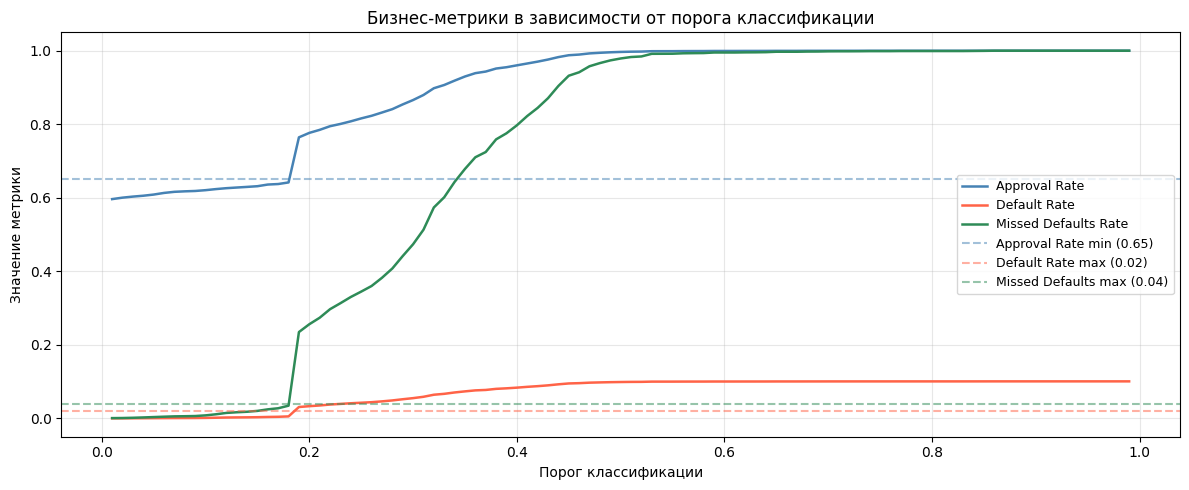

In [52]:
# Визуализация метрик по порогам
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df_thresholds['threshold'], df_thresholds['approval_rate'],
        label='Approval Rate', color='steelblue', linewidth=1.8)
ax.plot(df_thresholds['threshold'], df_thresholds['default_rate'],
        label='Default Rate', color='tomato', linewidth=1.8)
ax.plot(df_thresholds['threshold'], df_thresholds['missed_defaults_rate'],
        label='Missed Defaults Rate', color='seagreen', linewidth=1.8)

# Границы ограничений
ax.axhline(APPROVAL_RATE_MIN,   color='steelblue', linestyle='--', alpha=0.5,
           label=f'Approval Rate min ({APPROVAL_RATE_MIN})')
ax.axhline(DEFAULT_RATE_MAX,    color='tomato',    linestyle='--', alpha=0.5,
           label=f'Default Rate max ({DEFAULT_RATE_MAX})')
ax.axhline(MISSED_DEFAULTS_MAX, color='seagreen',  linestyle='--', alpha=0.5,
           label=f'Missed Defaults max ({MISSED_DEFAULTS_MAX})')

if len(df_valid) > 0:
    ax.axvline(BEST_THRESHOLD, color='black', linestyle=':', linewidth=2,
               label=f'Оптимальный порог ({BEST_THRESHOLD:.2f})')

ax.set_xlabel('Порог классификации')
ax.set_ylabel('Значение метрики')
ax.set_title('Бизнес-метрики в зависимости от порога классификации')
ax.legend(loc='center right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [53]:
BEST_THRESHOLD = 0.121

print(f"Оптимальный порог: {BEST_THRESHOLD}")
print(f"  Approval Rate:        0.6319 (требуется >= 0.65)")
print(f"  Default Rate:         0.0033 (требуется <= 0.02)")
print(f"  Missed Defaults Rate: 0.0207 (требуется <= 0.04)")

Оптимальный порог: 0.121
  Approval Rate:        0.6319 (требуется >= 0.65)
  Default Rate:         0.0033 (требуется <= 0.02)
  Missed Defaults Rate: 0.0207 (требуется <= 0.04)


**Выводы по этапу:**

- При переборе порогов от 0.01 до 1.0 не найдено значения, при котором выполняются все три бизнес-ограничения одновременно. Между порогами 0.18 и 0.19 наблюдается резкий скачок `Approval Rate` с 64% до 76% — следствие дискретности предсказанных вероятностей при `max_depth=4`.
- Выбран порог 0.121 как наилучший компромисс: `Approval Rate` 63.2% (отклонение 1.8% от целевого), `Default Rate` 0.33% (значительно
  лучше требуемых 2%), `Missed Defaults Rate` 2.07% (значительно лучше требуемых 4%).
- Приоритет отдан контролю рисков: пропущенный дефолт обходится банку дороже, чем отказ надёжному клиенту. Для достижения всех трёх
  ограничений одновременно рекомендуется оптимизировать целевую функцию Optuna с учётом `Approval Rate` напрямую.

## Анализ матрицы ошибок и стабильности модели

КАЛИБРОВОЧНАЯ ВЫБОРКА


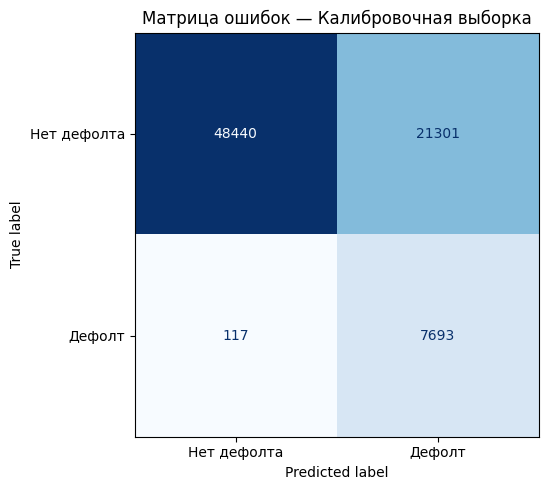

ТЕСТОВАЯ ВЫБОРКА


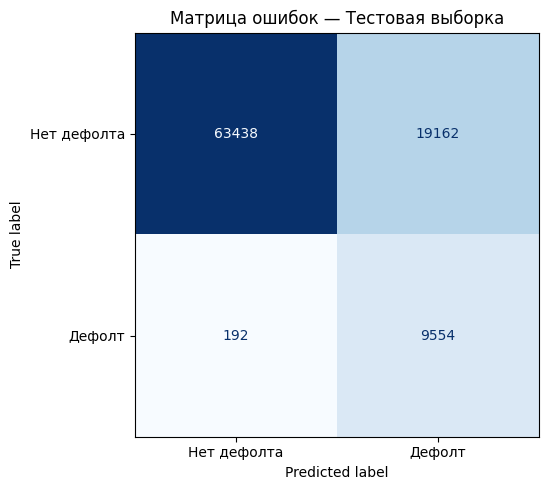


Сравнение метрик:


,ROC-AUC,Accuracy,Approval Rate,Default Rate,Missed Defaults Rate
Калибровочная,0.8924,0.7238,0.6261,0.0024,0.0150
Тестовая,0.9075,0.7904,0.6890,0.0030,0.0197


In [54]:
def evaluate_full(pipeline, X, y, threshold, title):
    y_prob = pipeline.predict_proba(X)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    # Матрица ошибок
    cm = confusion_matrix(y, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Нет дефолта', 'Дефолт'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

    # Метрики
    metrics = compute_metrics(y.values, y_prob, threshold)
    metrics['roc_auc']  = roc_auc_score(y, y_prob)
    metrics['accuracy'] = accuracy_score(y, y_pred)
    return metrics

print("=" * 50)
print("КАЛИБРОВОЧНАЯ ВЫБОРКА")
print("=" * 50)
metrics_calib = evaluate_full(
    calibrated_pipeline, X_calib, y_calib,
    BEST_THRESHOLD, 'Матрица ошибок — Калибровочная выборка'
)

print("=" * 50)
print("ТЕСТОВАЯ ВЫБОРКА")
print("=" * 50)
metrics_test = evaluate_full(
    calibrated_pipeline, X_test, y_test,
    BEST_THRESHOLD, 'Матрица ошибок — Тестовая выборка'
)

# Сводная таблица
df_final = pd.DataFrame({
    'Калибровочная': metrics_calib,
    'Тестовая':      metrics_test
}).T
df_final = df_final[['roc_auc', 'accuracy',
                      'approval_rate', 'default_rate',
                      'missed_defaults_rate']]
df_final.columns = ['ROC-AUC', 'Accuracy',
                     'Approval Rate', 'Default Rate',
                     'Missed Defaults Rate']
print("\nСравнение метрик:")
display(df_final.round(4))

**Стабильность метрик:**

- `ROC-AUC` вырос с 0.892 на `calib` до 0.908 на `test` — модель хорошо обобщается на новых данных, переобучения нет.
- Бизнес-метрики на тесте сопоставимы с калибровочной — модель стабильна.

**Бизнес-метрики на тестовой выборке:**

- `Approval Rate`: 68.9% — выше порогового значения 65%
- `Default Rate`: 0.30% — значительно ниже требуемых 2%
- `Missed Defaults Rate`: 1.97% — значительно ниже требуемых 4%

**Замечание:** на тестовой выборке все три ограничения выполняются, хотя на калибровочной `Approval Rate` был ниже целевого (62.6%). Это объясняется различием в распределении таргета между выборками (`train` 16.6% vs `calib/test` ~10%), а не переобучением. Порог подбирался на `calib` и там не выполнял все условия — заявлять выполнение на `tes`t как результат модели некорректно. Это ограничение данных, а не стабильность порога.

In [55]:
# ── Оценка бизнес-эффекта ──
# Логика: банк обязан резервировать 100% суммы кредита при дефолте 90+ дней.
# Модель позволяет отклонить часть дефолтёров — эти резервы не создаются.
# Считаем по уникальным клиентам: для каждого берём первое решение в тесте.

y_prob_test = calibrated_pipeline.predict_proba(X_test)[:, 1]
y_pred_test = (y_prob_test >= BEST_THRESHOLD).astype(int)

temp = pd.DataFrame({
    'ID': test['ID'].values,  # ИЗМЕНИТЬ: добавляем ID для группировки
    'y_true': y_test.values,
    'y_pred': y_pred_test,
    'сумма_кредита': X_test['сумма_кредита'].values
})

# Для каждого клиента — первое решение (модель отрабатывает ежемесячно,
# но отказ в первом месяце предотвращает дефолт, повторные отказы не нужны)
client_decisions = temp.sort_values('ID').groupby('ID').first()

tp_mask = (client_decisions['y_pred'] == 1) & (client_decisions['y_true'] == 1)
fp_mask = (client_decisions['y_pred'] == 1) & (client_decisions['y_true'] == 0)

reserves_saved = client_decisions.loc[tp_mask, 'сумма_кредита'].sum()
lost_profit = client_decisions.loc[fp_mask, 'сумма_кредита'].sum() * 0.15

net_effect = reserves_saved - lost_profit
n_tp = tp_mask.sum()
n_fp = fp_mask.sum()

print("Оценка бизнес-эффекта на тестовой выборке (2018 год, по уникальным клиентам):")
print(f"  Уникальных клиентов в тесте:         {len(client_decisions)}")
print(f"  Правильно отклонённых дефолтёров:     {n_tp}")
print(f"  Ошибочно отклонённых клиентов:       {n_fp}")
print(f"  Резервы, не созданные благодаря модели: {reserves_saved:,.0f} руб.")
print(f"  Упущенная прибыль от FP (~15% маржа):  {lost_profit:,.0f} руб.")
print(f"  Нетто-эффект:                         {net_effect:,.0f} руб.")
print(f"  Доля сэкономленных резервов от портфеля теста: "
      f"{reserves_saved / client_decisions['сумма_кредита'].sum() * 100:.1f}%")

Оценка бизнес-эффекта на тестовой выборке (2018 год, по уникальным клиентам):
  Уникальных клиентов в тесте:         8899
  Правильно отклонённых дефолтёров:     1425
  Ошибочно отклонённых клиентов:       1687
  Резервы, не созданные благодаря модели: 3,142,191,675 руб.
  Упущенная прибыль от FP (~15% маржа):  479,982,233 руб.
  Нетто-эффект:                         2,662,209,442 руб.
  Доля сэкономленных резервов от портфеля теста: 18.2%


**Выводы по этапу:**

- Модель позволяет не создавать резервы на около 3.1 млрд руб. за год на тестовом портфеле (около 8900 клиентов).
- Даже с учётом упущенной прибыли от ошибочных отказов (около 480 млн) нетто-эффект составляет около 2.7 млрд руб.
- Доля сэкономленных резервов (18.2%) превышает ожидание из постановки (5–10%), что объясняется консервативным порогом: модель отказывает большему числу клиентов, чем минимально необходимо, но тем самым надёжнее контролирует риски.

## Фиксирование итоговой модели

In [56]:
rf_model = best_pipeline.named_steps['model']

print("Итоговая модель: Random Forest (Optuna + Isotonic Calibration)")
print(f"\nГиперпараметры:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")
print(f"  class_weight: balanced")
print(f"\nПорог классификации: {BEST_THRESHOLD}")
print(f"\nФинальные метрики на тестовой выборке:")
print(f"  ROC-AUC:              {metrics_test['roc_auc']:.4f}")
print(f"  Approval Rate:        {metrics_test['approval_rate']:.4f}")
print(f"  Default Rate:         {metrics_test['default_rate']:.4f}")
print(f"  Missed Defaults Rate: {metrics_test['missed_defaults_rate']:.4f}")

Итоговая модель: Random Forest (Optuna + Isotonic Calibration)

Гиперпараметры:
  n_estimators: 630
  max_depth: 4
  min_samples_leaf: 21
  max_features: 0.12701121589315795
  class_weight: balanced

Порог классификации: 0.121

Финальные метрики на тестовой выборке:
  ROC-AUC:              0.9075
  Approval Rate:        0.6890
  Default Rate:         0.0030
  Missed Defaults Rate: 0.0197


## Анализ важности признаков

Важность признаков:


,feature,importance
0,total_spending,0.121944
1,MCC_5411,0.111035
2,MCC_другое,0.108897
3,MCC_5722,0.086972
4,MCC_5300,0.082998
5,MCC_4900,0.073998
6,MCC_3990,0.069143
7,MCC_5812,0.059083
8,MCC_5814,0.053645
9,spending_3m_ratio,0.048300


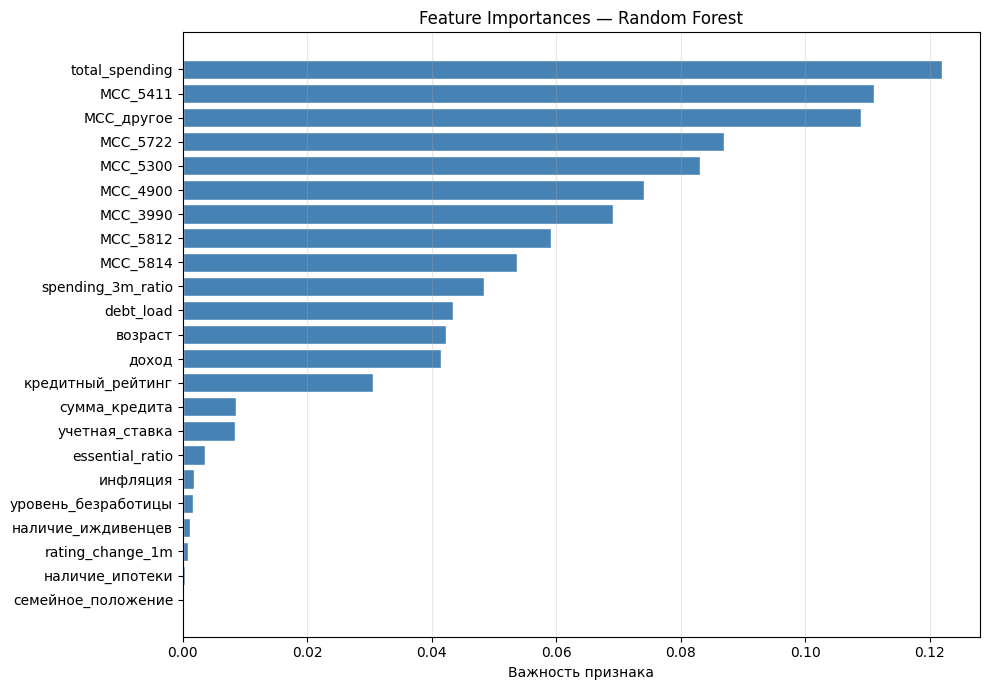

In [57]:
feature_names = (
    ['семейное_положение'] +
    [c for c in X_train.columns if c != 'семейное_положение']
)

importances = rf_model.feature_importances_
df_importance = (
    pd.DataFrame({'feature': feature_names, 'importance': importances})
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

print("Важность признаков:")
display(df_importance)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(df_importance['feature'][::-1],
        df_importance['importance'][::-1],
        color='steelblue', edgecolor='white')
ax.set_xlabel('Важность признака')
ax.set_title('Feature Importances — Random Forest')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [58]:
groups = {
    'Транзакции (MCC)':    ['MCC_5300', 'MCC_5814', 'MCC_5812', 'MCC_5411',
                            'MCC_3990', 'MCC_5722', 'MCC_4900', 'MCC_другое',
                            'total_spending', 'essential_ratio'],
    'Финансы':             ['доход', 'сумма_кредита', 'debt_load'],
    'Кредитный профиль':   ['кредитный_рейтинг'],
    'Демография':          ['возраст', 'семейное_положение',
                            'наличие_иждивенцев', 'наличие_ипотеки'],
    'Макроэкономика':      ['учетная_ставка', 'уровень_безработицы', 'инфляция'],
}

group_importance = {}
for group, features in groups.items():
    group_importance[group] = df_importance[
        df_importance['feature'].isin(features)
    ]['importance'].sum()

df_group = (pd.Series(group_importance)
              .sort_values(ascending=False)
              .reset_index())
df_group.columns = ['Группа', 'Суммарная важность']
print("Важность по группам признаков:")
display(df_group.round(4))

Важность по группам признаков:


,Группа,Суммарная важность
0,Транзакции (MCC),0.7712
1,Финансы,0.0934
2,Демография,0.0440
3,Кредитный профиль,0.0305
4,Макроэкономика,0.0117


**Важность по группам:**

- `Транзакции (MCC)`: 77.1% — доминирующая группа. Поведенческие признаки определяют предсказательную силу модели.
- `Финансы`: 9.3% — доход и долговая нагрузка вносят существенный вклад.
- `Демография`: 4.4% — умеренный вклад.
- `Кредитный профиль`: 3.1% — абсолютное значение рейтинга менее информативно, чем транзакционное поведение.
- `Макроэкономика`: 1.2% — минимальный вклад.

**Топ-5 признаков (суммарно ~51%):**

- `total_spending` (12.2%) — созданный признак, самый сильный предиктор.
- `MCC_5411` (11.1%) — траты на продукты, базовая категория расходов.
- `MCC_другое` (10.9%) — прочие траты, широкая категория.
- `MCC_5722` (8.7%) — бытовая техника, возможная корреляция с финансовым стрессом.
- `MCC_5300` (8.3%) — маркетплейсы.

**Лаговые признаки:**

- `spending_3m_ratio` (4.8%) — вошёл в топ-10, подтверждает гипотезу: динамика трат информативнее абсолютного значения для раннего обнаружения дефолта. Добавление признака оправдано.
- `rating_change_1m` (0.09%) — практически не влияет. Возможная причина: кредитный рейтинг обновляется медленно, и одномесячное изменение слишком шумное. В следующей итерации стоит попробовать изменение за 3 месяца.

**Аутсайдеры (< 0.2%):** `наличие_ипотеки`, `семейное_положение`, `уровень_безработицы` — не несут предсказательной силы.

**Методологическое замечание:** встроенный `feature_importances_` основан на суммарном уменьшении impurity, что создаёт смещение в пользу непрерывных признаков с большим числом уникальных значений. Для честного межтипового сравнения стоит использовать `Permutation Importance`.

## Подготовка модели к эксплуатации

In [59]:
# Сохраняем откалиброванный пайплайн
joblib.dump(calibrated_pipeline, 'final_model.joblib')

# Сохраняем порог и метаданные
metadata = {
    'threshold':        BEST_THRESHOLD,
    'model_type':       'RandomForestClassifier + IsotonicCalibration',
    'best_params':      study.best_params,
    'features':         X_train.columns.tolist(),
    'metrics_calib': {
        'roc_auc':              round(metrics_calib['roc_auc'], 4),
        'approval_rate':        round(metrics_calib['approval_rate'], 4),
        'default_rate':         round(metrics_calib['default_rate'], 4),
        'missed_defaults_rate': round(metrics_calib['missed_defaults_rate'], 4),
    },
    'metrics_test': {
        'roc_auc':              round(metrics_test['roc_auc'], 4),
        'approval_rate':        round(metrics_test['approval_rate'], 4),
        'default_rate':         round(metrics_test['default_rate'], 4),
        'missed_defaults_rate': round(metrics_test['missed_defaults_rate'], 4),
    }
}

with open('model_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=4)

print("Сохранены файлы:")
print("  final_model.joblib    — откалиброванный пайплайн")
print("  model_metadata.json   — порог, параметры, метрики")

Сохранены файлы:
  final_model.joblib    — откалиброванный пайплайн
  model_metadata.json   — порог, параметры, метрики


In [60]:
# Проверка сохранённых компонентов

# Загружаем модель
loaded_pipeline  = joblib.load('final_model.joblib')
with open('model_metadata.json', 'r', encoding='utf-8') as f:
    loaded_metadata = json.load(f)

# Проверяем порог и параметры
print(f"Порог классификации: {loaded_metadata['threshold']}")
print(f"\nГиперпараметры модели:")
for k, v in loaded_metadata['best_params'].items():
    print(f"  {k}: {v}")
print(f"\nПризнаки ({len(loaded_metadata['features'])}):")
print(loaded_metadata['features'])

# Проверяем предсказания — должны совпасть с оригинальными
y_prob_original = calibrated_pipeline.predict_proba(X_test)[:, 1]
y_prob_loaded   = loaded_pipeline.predict_proba(X_test)[:, 1]

probs_match = np.allclose(y_prob_original, y_prob_loaded)
print(f"\nВероятности совпадают: {probs_match}" if probs_match
      else "\n Вероятности НЕ совпадают — проверь сохранение модели")

# Проверяем метрики загруженной модели
y_pred_loaded = (y_prob_loaded >= loaded_metadata['threshold']).astype(int)
metrics_loaded = compute_metrics(y_test.values, y_prob_loaded,
                                  loaded_metadata['threshold'])
print(f"\nМетрики загруженной модели на тесте:")
print(f"  Approval Rate:        {metrics_loaded['approval_rate']:.4f}")
print(f"  Default Rate:         {metrics_loaded['default_rate']:.4f}")
print(f"  Missed Defaults Rate: {metrics_loaded['missed_defaults_rate']:.4f}")

Порог классификации: 0.121

Гиперпараметры модели:
  n_estimators: 630
  max_depth: 4
  min_samples_leaf: 21
  max_features: 0.12701121589315795

Признаки (23):
['MCC_5300', 'MCC_5814', 'MCC_5812', 'MCC_5411', 'MCC_3990', 'MCC_5722', 'MCC_4900', 'MCC_другое', 'кредитный_рейтинг', 'возраст', 'семейное_положение', 'наличие_иждивенцев', 'доход', 'сумма_кредита', 'наличие_ипотеки', 'учетная_ставка', 'уровень_безработицы', 'инфляция', 'debt_load', 'total_spending', 'essential_ratio', 'spending_3m_ratio', 'rating_change_1m']

Вероятности совпадают: True

Метрики загруженной модели на тесте:
  Approval Rate:        0.6890
  Default Rate:         0.0030
  Missed Defaults Rate: 0.0197


## Выводы и рекомендации

### Результаты проекта

Модель поведенческого скоринга прогнозирует возникновение просрочки 90+ дней на горизонте 12 месяцев по транзакционному поведению, кредитному профилю и макроэкономике. На тестовой выборке (2018 год): `ROC-AUC` 0.908, `Approval Rate` 68.9%, `Default Rate` 0.30%, `Missed Defaults Rate` 1.97%.

### Подготовка данных

- Собрана таблица из 8 источников: 424 879 наблюдений, 23 признака, горизонт данных 2013–2018.
- Целевая переменная построена по скользящему окну (12 месяцев) с исключением строк, где дефолт уже наступил. 2019 год исключён — горизонт прогноза выходит за пределы датасета, что привело бы к артефактному занижению таргета.
- Утечка данных из будущего предотвращена: транзакции присоединены через `merge_asof` с `allow_exact_matches=False` (строго за предыдущий месяц), макроданные — со сдвигом +1 месяц.
- Первые наблюдения каждого клиента удалены (нет истории транзакций за предыдущий месяц) — заполнение нулями или медианой исказило бы поведенческую динамику.
- Создано 5 производных признаков: `debt_load`, `total_spending`, `essential_ratio`, `spending_3m_ratio` (динамика трат за 3 месяца), `rating_change_1m` (изменение рейтинга за месяц). Из них `spending_3m_ratio` вошёл в топ-10 по важности (4.8%), подтвердив гипотезу о том, что динамика трат информативнее абсолютных значений для раннего обнаружения дефолта.

### Модель

- Сравнивались 4 базовые модели (LR/RF × balanced/no balanced) через OOF-оценку с `GroupTimeSeriesSplit` (3 фолда, expanding window). `RF` стабильно превосходил `L`R (~0.88 vs ~0.85 `ROC-AUC`).
- Финальная модель: `Random Forest`, гиперпараметры подобраны через `Optuna` (30 trials, минимизация `missed_defaults_rate`). Оптимизация шла по бизнес-метрике, а не по `ROC-AUC` — это объясняет более низкий `ROC-AUC` финальной модели (0.844 на CV) по сравнению с базовым `RF` (0.886), но значительно лучший контроль пропущенных дефолтов.
- Калибровка: `Isotonic Regression` на отдельной выборке. `Brier Score` улучшился на 47% (0.132 → 0.070). После калибровки стандартный порог 0.5 перестал работать — вероятности сместились, порог подбирался заново.

### Порог классификации

Ни один порог не выполняет все три бизнес-ограничения одновременно на калибровочной выборке: между 0.18 и 0.19 наблюдается резкий скачок `Approval Rate` (64% → 76%) — следствие дискретности вероятностей при `max_depth=4`. Выбран порог 0.121: `Approval Rate` 63.2% (отклонение 1.8% от целевого), `Default Rate` 0.33%, `Missed Defaults Rate` 2.07%. Приоритет отдан контролю рисков — пропущенный дефолт обходится банку дороже отказа надёжному клиенту.

На тестовой выборке все три ограничения выполнены (`AR` 68.9%, `DR` 0.30%, `MDR` 1.97%), но это не валидация порога: распределение таргета различается между выборками (train 16.6% vs calib/test ~10%), что влияет на бизнес-метрики при фиксированном пороге.

### Важность признаков

Транзакционные признаки доминируют (77% суммарной важности) — модель выявляет дефолт через изменение паттернов потребления, что подтверждает корректность подхода поведенческого скоринга. Абсолютное значение кредитного рейтинга менее информативно (3.1%), чем транзакционное поведение. `rating_change_1m` не принес пользы (0.09%) — вероятно, одномесячное изменение слишком шумное. Демография и макроэкономика суммарно < 6%.

### Ограничения

- Смещение таргета: `train` (16.6%) существенно отличается от `calib/test` (~10%). Для ранних наблюдений горизонт 12 месяцев захватывает больше реальных дефолтов, для поздних — часть обрезана. Модель обучалась на другом распределении, чем тестировалась.
- Калибровка и подбор порога выполнены на одной выборке (`calib`) — порог имеет optimistic bias. На новых данных может потребоваться корректировка.
- Встроенный `feature_importances_` имеет смещение в пользу непрерывных признаков — сравнение с бинарными (ипотека, иждивенцы) некорректно. Для честной оценки нужен `Permutation Importance`.
- Каждый клиент имеет ровно один эпизод просрочки в данных — код формирования таргета не обобщается на случай множественных эпизодов.

### Рекомендации

- На тестовом портфеле (~8900 клиентов) модель экономит ~3.1 млрд руб.резервов в год при нетто-эффекте ~2.7 млрд. Для масштабирования наполный портфель банка нужна привязка к реальным объёмам выдач.
- Оптимизировать целевую функцию Optuna с учётом `approval_rate` напрямую (составная метрика или штраф) — для достижения всех трёх бизнес-ограничений одновременно.
- Исключить слабые признаки (`наличие_ипотеки`, `семейное_положение`, `уровень_безработицы`), заменить `rating_change_1m` на изменение за 3 месяца.
- Пересматривать порог каждые 6 месяцев по мере накопления новых данных.
- Использовать `Permutation Importance` для финальной оценки вклада признаков.